# <center style="font-weight: bold; color: #0098cd;">Procesamiento del lenguaje natural: clasificación y extracción de entidades</center>

## 1. Introducción

El procesamiento del lenguaje natural (*Natural Language Processing*, NLP) constituye la etapa encargada de transformar las transcripciones generadas por el sistema ASR en información estructurada con significado semántico. El reto principal radica en la variabilidad del lenguaje natural, la presencia de ruido procedente de la transcripción automática y la necesidad de extraer información relevante en un dominio específico como el agrícola.

Este *notebook* aborda el diseño, implementación y evaluación de un sistema de análisis lingüístico que combina tareas de clasificación de mensajes y reconocimiento de entidades (*Named Entity Recognition*, NER). Se adopta un enfoque híbrido que integra modelos de aprendizaje automático con conocimiento de dominio, permitiendo mejorar la cobertura del sistema en escenarios con datos limitados.

Además, se incorporan mecanismos de evaluación y análisis que permiten no solo medir el rendimiento del sistema, sino también identificar sus limitaciones, analizar errores y comprender el impacto de las decisiones de diseño en la calidad de los resultados obtenidos.

### 1.1 Objetivo

El objetivo de este *notebook* es desarrollar un sistema de procesamiento del lenguaje natural capaz de clasificar automáticamente los mensajes generados por el sistema ASR en categorías predefinidas, así como de extraer entidades relevantes del dominio agrícola a partir del texto. De forma complementaria, se persigue evaluar el rendimiento del sistema mediante métricas cuantitativas y análisis de errores, con el fin de validar su comportamiento en condiciones cercanas a un entorno real.

👉 siguiente paso: definir **estructura exacta del JSON final + diccionario de normalización LATAM**
Ahí es donde tu TFM pasa de bueno a muy sólido.

### 1.2 Contexto dentro del sistema completo

El módulo NLP constituye la tercera etapa del sistema, actuando como puente entre la transcripción automática del habla y la generación de información estructurada. Su función principal es transformar el texto generado por el ASR en representaciones semánticas que puedan ser utilizadas en etapas posteriores, como la normalización y estructuración de la información.

La calidad de esta etapa depende directamente de la precisión del sistema ASR, ya que los errores de transcripción pueden afectar tanto a la clasificación de mensajes como a la detección de entidades. En este sentido, el análisis desarrollado en este notebook permite evaluar cómo se propagan dichos errores y qué impacto tienen en la interpretación del contenido.

Asimismo, este módulo introduce una capa de inteligencia semántica en el sistema, permitiendo pasar de datos no estructurados a información interpretable.

### 1.3 Requisitos de esta fase

El desarrollo del módulo NLP se rige por una serie de requisitos funcionales y de diseño que garantizan su coherencia dentro del sistema completo.

En primer lugar, se requiere disponer de un mecanismo capaz de clasificar los mensajes generados por el sistema ASR en categorías predefinidas, permitiendo determinar el tipo de información contenida en cada mensaje y condicionando su tratamiento en etapas posteriores del sistema, como la creación de nuevos registros o la actualización de eventos asociados a un usuario.

En segundo lugar, es necesario implementar un sistema de extracción de entidades que permita identificar información relevante del dominio agrícola presente en el texto.

Asimismo, se debe garantizar la correcta integración de ambas tareas dentro del flujo global de procesamiento, manteniendo una estructura modular que facilite la reutilización de componentes, la trazabilidad de los resultados y la extensión futura del sistema.

Adicionalmente, es fundamental preservar la consistencia entre las distintas fases del procesamiento, asegurando que las salidas generadas puedan ser utilizadas como entrada en etapas posteriores sin pérdida de información.

Finalmente, el sistema debe permitir la evaluación de su rendimiento mediante métricas adecuadas, así como el análisis de errores, con el objetivo de identificar limitaciones y establecer posibles líneas de mejora.

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno técnico necesario para el desarrollo del módulo de procesamiento del lenguaje natural, centrado en la clasificación de mensajes y la extracción de entidades. Se incluyen la instalación de dependencias, la importación de librerías especializadas y la configuración de rutas de trabajo.

El objetivo es garantizar un entorno reproducible y estructurado que permita ejecutar de forma consistente las distintas etapas del pipeline NLP, incluyendo el entrenamiento, evaluación y aplicación de los modelos de clasificación y reconocimiento de entidades. Asimismo, se establece una organización clara de los directorios que facilita la separación entre datos de entrenamiento, conjuntos de evaluación, modelos generados y resultados obtenidos.

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

#### 2.1.1 Configuración del entorno

Este *notebook* requiere la instalación previa de las dependencias del proyecto.

Ejecutar en terminal:

```bash
pip install -r requirements.txt
python -m spacy download es_core_news_md
```

### 2.2 Importación de librerías

Se importan las librerías necesarias para las distintas fases del procesamiento, incluyendo manipulación de señal, tratamiento de audio, modelos de detección de voz, análisis de datos y visualización.

Se organiza por bloques funcionales para permitir identificar claramente el propósito de cada conjunto de herramientas dentro del *pipeline*, facilitando la mantenibilidad y comprensión del código.

In [ ]:
# ==============================
# GESTIÓN DE RUTAS Y SISTEMA
# ==============================
from pathlib import Path
import json

# ==============================
# MANIPULACIÓN DE DATOS
# ==============================
import pandas as pd
import numpy as np

# ==============================
# PROCESAMIENTO DE TEXTO
# ==============================
import re
import unicodedata
from unidecode import unidecode

# ==============================
# MACHINE LEARNING (CLASIFICACIÓN)
# ==============================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# NLP (NER Y MODELOS TRANSFORMER)
# ==============================
import spacy
from spacy.training.example import Example
from spacy.training import offsets_to_biluo_tags
from spacy.scorer import Scorer

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    logging,
    set_seed
)

import torch

# ==============================
# UTILIDADES
# ==============================
from tqdm import tqdm
import joblib
import random
from collections import Counter

# ==============================
# VISUALIZACIÓN
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### 2.3 Gestión y configuración de rutas

In [ ]:
# =========================
# DETECCIÓN DE RAÍZ
# =========================

project_root = Path.cwd()

while not (project_root / "data").exists():
    if project_root == project_root.parent:
        raise FileNotFoundError("No se ha encontrado la carpeta 'data' en la ruta actual ni en sus directorios superiores.")
    project_root = project_root.parent


# =========================
# DIRECTORIOS
# =========================

# Ruta raíz de datos
data_dir = project_root / "data"


# =========================
# CONFIGURACIÓN
# =========================

# Carpeta de configuración
config_dir = data_dir / "config"

# Subcarpetas de configuración
domain_config_dir = config_dir / "domain"
ner_config_dir = config_dir / "ner"
asr_config_dir = config_dir / "asr"

# Archivos de configuración
ner_entities_path = ner_config_dir / "ner_entities.json"

# Diccionario de términos para NER (detección)
ner_terms_path = ner_config_dir / "coffee_cacao_ner_terms.json"


# =========================
# DATASETS
# =========================

datasets_dir = data_dir / "datasets"

# NER
ner_dataset_dir = datasets_dir / "ner"
ner_annotated_dir = ner_dataset_dir / "annotated"
ner_evaluation_dir = ner_dataset_dir / "evaluation"

# Rutas
ner_dataset_path = ner_annotated_dir / "ner_dataset.json"
ner_evaluation_path = ner_evaluation_dir / "ner_evaluation_dataset.json"


# =========================
# TRANSCRIPCIONES (INPUT NLP)
# =========================

transcriptions_dir = data_dir / "transcriptions"
pred_asr_dir = transcriptions_dir / "asr_output"
ground_truth_dir = transcriptions_dir / "ground_truth"


# =========================
# SALIDA NLP
# =========================

structured_data_dir = data_dir / "structured_data"

# Salida del pipeline NLP (clasificación + NER)
nlp_output_dir = structured_data_dir / "nlp_output"

# Salida final tras normalización
normalized_output_dir = structured_data_dir / "normalized_output"


# =========================
# MODELOS NLP
# =========================

models_dir = data_dir / "models"

classification_model_dir = models_dir / "classification_model"
ner_model_dir = models_dir / "ner_model"


# =========================
# CREACIÓN DE CARPETAS
# =========================

# Configuración
domain_config_dir.mkdir(parents=True, exist_ok=True)
ner_config_dir.mkdir(parents=True, exist_ok=True)
asr_config_dir.mkdir(parents=True, exist_ok=True)

# Datasets
ner_dataset_dir.mkdir(parents=True, exist_ok=True)
ner_annotated_dir.mkdir(parents=True, exist_ok=True)
ner_evaluation_dir.mkdir(parents=True, exist_ok=True)

# Salida NLP
nlp_output_dir.mkdir(parents=True, exist_ok=True)
normalized_output_dir.mkdir(parents=True, exist_ok=True)

# Modelos
classification_model_dir.mkdir(parents=True, exist_ok=True)
ner_model_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz:", project_root)

print("\n--- Configuración ---")
print("NER entities:", ner_entities_path)
print("NER terms:", ner_terms_path)

print("\n--- Datasets ---")
print("NER train dataset:", ner_dataset_path)
print("NER evaluation dataset:", ner_evaluation_path)

print("\n--- Input NLP ---")
print("Transcripciones procesadas:", pred_asr_dir)
print("Ground truth:", ground_truth_dir)

print("\n--- Output NLP ---")
print("Salida NLP (clasificación + NER):", nlp_output_dir)
print("Salida final normalizada:", normalized_output_dir)

print("\n--- Modelos NLP ---")
print("Modelo clasificación:", classification_model_dir)
print("Modelo NER:", ner_model_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM

--- Configuración ---
NER entities: /Volumes/EXTENSION/GitHub/TFM/data/config/ner/ner_entities.json
NER terms: /Volumes/EXTENSION/GitHub/TFM/data/config/ner/coffee_cacao_ner_terms.json

--- Datasets ---
NER train dataset: /Volumes/EXTENSION/GitHub/TFM/data/datasets/ner/annotated/ner_dataset.json
NER evaluation dataset: /Volumes/EXTENSION/GitHub/TFM/data/datasets/ner/evaluation/ner_evaluation_dataset.json

--- Input NLP ---
Transcripciones procesadas: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Ground truth: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/ground_truth

--- Output NLP ---
Salida NLP (clasificación + NER): /Volumes/EXTENSION/GitHub/TFM/data/structured_data/nlp_output
Salida final normalizada: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/normalized_output

--- Modelos NLP ---
Modelo clasificación: /Volumes/EXTENSION/GitHub/TFM/data/models/classification_model
Modelo NER: /Volumes/EXTENSION/GitHub/TFM/data/m

## 3. Preparación del dataset para NLP

En esta sección se construye el conjunto de datos utilizado en las tareas de procesamiento del lenguaje natural, integrando tanto las transcripciones generadas automáticamente por el sistema ASR como las anotaciones manuales del *ground truth*. Este proceso permite disponer de una base homogénea sobre la que aplicar las etapas posteriores de análisis y modelado.

### 3.1 Carga de transcripciones

Se realiza la carga de las transcripciones procedentes del sistema ASR y del conjunto de referencia manual, estructurando ambos conjuntos de datos en un formato común. Esta unificación facilita su uso en las etapas posteriores del *pipeline*, garantizando la consistencia en la representación del texto y las etiquetas asociadas.

In [21]:
# -------- ASR --------

# Carga de archivos JSON del ASR
json_paths = sorted(list(pred_asr_dir.glob("*.json")))

dataset_asr = []

for path in json_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        dataset_asr.append({
            "audio_id": data.get("audio_id", path.stem),
            "text": data.get("text", "")
        })
        
    except Exception as e:
        dataset_asr.append({
            "audio_id": path.stem,
            "text": None,
            "error": str(e)
        })

# Conversión a DataFrame
df_asr = pd.DataFrame(dataset_asr)

print(f"ASR cargado: {len(df_asr)} registros")
display(df_asr.head())


# -------- GROUND TRUTH --------

# Carga de anotaciones manuales
gt_path = ground_truth_dir / "ground_truth.csv"

df_gt = pd.read_csv(gt_path)

print(f"Ground truth cargado: {len(df_gt)} registros")

# Estandarización de columnas para NLP
df_gt = df_gt.rename(columns={
    "transcripcion": "text",
    "clase": "label"
})

display(df_gt.head())

ASR cargado: 200 registros


,audio_id,text
0,AUDIO_00001,"Bueno, hoy estuvimos haciendo deshierbe en el ..."
1,AUDIO_00002,"Mi nombre es Luis Fernando Taborda, soy produc..."
2,AUDIO_00003,"Entonces, estamos aplicando fertilizante orgán..."
3,AUDIO_00004,"Ayer estuvimos recogiendo cacao, no mucho, per..."
4,AUDIO_00005,"Hola, me llamo Carlos Ramírez, soy productor d..."


Ground truth cargado: 200 registros


,audio_id,text,label
0,AUDIO_00001,"Bueno, hoy estuvimos haciendo deshierbe en el ...",evento_cultivo
1,AUDIO_00002,"Mi nombre es Luis Fernando Taborda, soy produc...",registro_inicial
2,AUDIO_00003,entonces estamos aplicando fertilizante orgáni...,evento_cultivo
3,AUDIO_00004,Ayer estuvimos recogiendo cacao no mucho pero ...,evento_cultivo
4,AUDIO_00005,"Hola, me llamo Carlos Ramírez, soy productor d...",registro_inicial


### 3.2 Normalización de texto para PLN

Se aplica una normalización ligera del texto con el objetivo de reducir la variabilidad superficial asociada a aspectos como la capitalización, la codificación Unicode y la presencia de espacios redundantes. Este proceso permite homogeneizar la representación del texto sin alterar su contenido semántico, preservando así la información lingüística relevante para las tareas de clasificación y reconocimiento de entidades.

### 3.2.1 Función de normalización de texto

A continuación, se define la función encargada de aplicar el proceso de normalización sobre cada texto del conjunto de datos. Esta función implementa de forma sistemática las transformaciones descritas previamente, garantizando una aplicación homogénea del preprocesamiento en todas las etapas del pipeline.

In [22]:
def normalize_for_nlp(text):
    
    if text is None:
        return ""
    
    # minúsculas
    text = text.lower()
    
    # normalización unicode (mantiene acentos correctamente)
    text = unicodedata.normalize("NFKC", text)
    
    # eliminación de espacios duplicados
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

### 3.2.2 Aplicación de la normalización al *dataset*

In [23]:
df_asr["text_clean"] = df_asr["text"].apply(normalize_for_nlp)
df_gt["text_clean"] = df_gt["text"].apply(normalize_for_nlp)

### 3.2 Validación de datos

A continuación, se evalúa la calidad de los datos utilizados en el pipeline de procesamiento del lenguaje natural, con el objetivo de garantizar la consistencia y fiabilidad de las entradas. Este proceso permite identificar registros incompletos o no válidos que podrían afectar negativamente al rendimiento de los modelos.

#### 3.2.1 Validación del *dataset* ASR

Se realiza la validación de las transcripciones generadas automáticamente por el sistema ASR, comprobando que los textos procesados sean válidos y utilizables. Este análisis permite detectar posibles errores derivados del proceso de transcripción o de la calidad del audio de entrada.

In [24]:
# Texto válido: no vacío y tipo string
df_asr["text_valid"] = df_asr["text_clean"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Filtrado
valid_asr = df_asr[df_asr["text_valid"]].copy()
invalid_asr = df_asr[~df_asr["text_valid"]].copy()

print(f"ASR → válidos: {len(valid_asr)}, inválidos: {len(invalid_asr)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_asr) > 0:
    print("\nEjemplos inválidos ASR:")
    display(invalid_asr.head())

ASR → válidos: 200, inválidos: 0


#### 3.2.2 Validación del *dataset Ground Truth*

Se verifica la calidad del conjunto de referencia manual, asegurando tanto la validez de los textos como la presencia de etiquetas asociadas. Esta validación resulta fundamental para garantizar la fiabilidad del proceso de entrenamiento y evaluación del modelo.

In [25]:
# Texto válido
df_gt["text_valid"] = df_gt["text_clean"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Label válido (no nulo)
df_gt["label_valid"] = df_gt["label"].notnull()

# Filtrado
valid_gt = df_gt[(df_gt["text_valid"]) & (df_gt["label_valid"])].copy()
invalid_gt = df_gt[~((df_gt["text_valid"]) & (df_gt["label_valid"]))].copy()

print(f"GT → válidos: {len(valid_gt)}, inválidos: {len(invalid_gt)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_gt) > 0:
    print("\nEjemplos inválidos GT:")
    display(invalid_gt.head())

GT → válidos: 200, inválidos: 0


### 3.3 Análisis inicial del *dataset Ground Truth*

In [26]:
print("Distribución de clases:")
print(valid_gt["label"].value_counts())

print("\nDistribución relativa (%):")
print((valid_gt["label"].value_counts(normalize=True) * 100).round(2))

Distribución de clases:
label
evento_cultivo      134
registro_inicial     66
Name: count, dtype: int64

Distribución relativa (%):
label
evento_cultivo      67.0
registro_inicial    33.0
Name: proportion, dtype: float64


La distribución de clases obtenida no se corresponde con el equilibrio inicialmente planteado, observándose un predominio de la clase *evento_cultivo* frente a *registro_inicial*. Esta situación es coherente con la naturaleza de los datos, ya que el registro inicial se realiza una única vez por productor, mientras que los eventos de cultivo se generan de forma recurrente a lo largo del tiempo. Este desbalanceo deberá ser tenido en cuenta en las fases posteriores del proceso de modelado.

## 4. Clasificación de mensajes

En esta sección se aborda el desarrollo del sistema de clasificación de mensajes, cuyo objetivo es categorizar automáticamente los textos generados por el sistema ASR en un conjunto de clases predefinidas. Esta tarea permite identificar el tipo de información contenida en cada mensaje y condiciona su tratamiento en las etapas posteriores del sistema.

Para ello, se parte de un conjunto de datos etiquetado que se utiliza para entrenar y evaluar distintos modelos de clasificación, analizando su rendimiento mediante métricas cuantitativas. A lo largo de la sección se describen las fases de preparación de los datos, entrenamiento de los modelos y evaluación de resultados.

Asimismo, se comparan diferentes enfoques de clasificación, desde modelos base hasta modelos basados en *transformers*, con el objetivo de seleccionar la configuración más adecuada para su integración en el *pipeline* final del sistema.

### 4.1 Definición de clases a partir del conocimiento del dominio

En este apartado se describen las clases objetivo del problema de clasificación, definidas a partir del conocimiento del dominio y del proceso de etiquetado realizado con apoyo de expertos.

Durante la fase de construcción del dataset, los mensajes fueron anotados manualmente siguiendo criterios establecidos en colaboración con profesionales del ámbito agronómico, quienes identificaron dos tipos principales de información:

- `registro_inicial` mensajes que contienen información descriptiva del productor o de la parcela, utilizados como punto de partida del sistema.
- `evento_cultivo`: mensajes asociados a actividades, incidencias o prácticas agronómicas registradas de forma recurrente en la finca.

Esta categorización refleja la estructura real del flujo de información generado por los productores y permite abordar el problema como una tarea de clasificación binaria alineada con el uso final del sistema.

### 4.2 Preparación del *dataset*

En esta etapa se construye el conjunto de datos final que será utilizado en el entrenamiento del modelo de clasificación, seleccionando las variables relevantes y asegurando su consistencia. Este proceso permite definir una representación estructurada del problema, en la que cada instancia queda asociada a su correspondiente etiqueta.

In [27]:
# Mantenemos las columnas necesarias para el modelo: identificador, texto limpio y clase.
df_model = valid_gt[["audio_id", "text_clean", "label"]].copy()

# Codificación de etiquetas
label_encoder = LabelEncoder()
df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

# Verificación del tamaño del dataset resultante
print(f"Dataset: {len(df_model)} registros")

# Inspección inicial de los datos
df_model.head()

Dataset: 200 registros


,audio_id,text_clean,label,label_encoded
0,AUDIO_00001,"bueno, hoy estuvimos haciendo deshierbe en el ...",evento_cultivo,0
1,AUDIO_00002,"mi nombre es luis fernando taborda, soy produc...",registro_inicial,1
2,AUDIO_00003,entonces estamos aplicando fertilizante orgáni...,evento_cultivo,0
3,AUDIO_00004,ayer estuvimos recogiendo cacao no mucho pero ...,evento_cultivo,0
4,AUDIO_00005,"hola, me llamo carlos ramírez, soy productor d...",registro_inicial,1


### 4.3 Codificación de etiquetas

Se procede a la transformación de las etiquetas categóricas en valores numéricos, requisito necesario para su uso en modelos de aprendizaje automático. Esta codificación permite mantener una correspondencia explícita entre las clases originales y su representación interna en el modelo.

In [28]:
# Codificación de etiquetas a valores numéricos para el modelo
label_encoder = LabelEncoder()

df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'evento_cultivo': np.int64(0), 'registro_inicial': np.int64(1)}


### 4.4 División del *dataset* en entrenamiento y test

La división del *dataset* se realiza manteniendo la proporción original de clases mediante una estrategia de partición estratificada. Dado el desbalance existente entre clases, se aplica posteriormente un proceso de balanceo sobre el conjunto de entrenamiento, con el objetivo de mejorar la capacidad del modelo para aprender patrones representativos de ambas clases.

In [99]:
# División del dataset
X = df_model["text_clean"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Construcción correcta del DataFrame (alineado)
df_train = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

# Balanceo manual
class_counts = df_train["label"].value_counts()
min_class_size = class_counts.min()

df_class_0 = df_train[df_train["label"] == class_counts.index[0]].sample(n=min_class_size, random_state=42)
df_class_1 = df_train[df_train["label"] == class_counts.index[1]].sample(n=min_class_size, random_state=42)

df_train_balanced = pd.concat([df_class_0, df_class_1]) \
    .sample(frac=1, random_state=42) \
    .reset_index(drop=True)

# Separación final para BETO (formato limpio)
X_train_texts = df_train_balanced["text"].tolist()
y_train_labels = df_train_balanced["label"].tolist()

X_test_texts = X_test.tolist()
y_test_labels = y_test.reset_index(drop=True).tolist()

#### 4.4.1 Análisis de la distribución de clases en entrenamiento y test

In [100]:
print("Distribución TRAIN (balanceado):")
print(pd.Series(y_train_labels).value_counts())
print(pd.Series(y_train_labels).value_counts(normalize=True))

print("\nDistribución TEST (real):")
print(pd.Series(y_test_labels).value_counts())
print(pd.Series(y_test_labels).value_counts(normalize=True))

Distribución TRAIN (balanceado):
1    53
0    53
Name: count, dtype: int64
1    0.5
0    0.5
Name: proportion, dtype: float64

Distribución TEST (real):
0    27
1    13
Name: count, dtype: int64
0    0.675
1    0.325
Name: proportion, dtype: float64


Tras la aplicación del balanceo, el conjunto de entrenamiento presenta una distribución completamente equilibrada entre clases, mientras que el conjunto de test conserva la distribución original del problema, con un predominio de la clase mayoritaria.

Este enfoque permite entrenar el modelo en condiciones controladas, reduciendo el sesgo durante el aprendizaje, y evaluar su rendimiento en un escenario representativo del uso real, donde el desbalance forma parte inherente de los datos.

### 4.5 Modelado

En este apartado se aborda el modelado del problema de clasificación de mensajes a partir del texto transcrito. Para ello, se plantean dos enfoques diferenciados:
- Un modelo *baseline* basado en representaciones clásicas del texto
- Un modelo basado en transformers mediante el uso de BETO.

El modelo *baseline* se construye utilizando una representación TF-IDF de los textos junto con un clasificador de regresión logística. Esta elección responde a su eficacia contrastada en tareas de clasificación de texto, especialmente en escenarios con conjuntos de datos reducidos, donde ofrece un buen equilibrio entre rendimiento, estabilidad y coste computacional. Además, permite establecer una referencia objetiva sobre la que evaluar posteriormente el impacto del uso de modelos más complejos.

A partir de esta base, se incorpora un segundo enfoque basado en BETO, que permite capturar información contextual más rica del lenguaje. La comparación entre ambos enfoques permitirá analizar si el incremento de complejidad introduce mejoras en el rendimiento dentro del contexto del problema planteado, o si, por el contrario, un modelo más simple resulta suficiente.

#### 4.5.1 Modelo baseline (TF-IDF + *Logistic Regression*)

Se implementa un modelo de referencia basado en representaciones clásicas del texto mediante TF-IDF, combinado con un clasificador de regresión logística. Este enfoque permite capturar la importancia de los términos en función de su frecuencia relativa y establecer una base sólida para la comparación con modelos más complejos.

In [101]:
# Vectorización TF-IDF y entrenamiento del modelo baseline
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train_texts)
X_test_tfidf = vectorizer.transform(X_test_texts)

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_tfidf, y_train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### 4.5.2 Modelo basado en BETO (*fine-tuning*)

Se incorpora un modelo basado en la arquitectura BERT adaptada al español (BETO), con el objetivo de capturar información contextual del lenguaje. A diferencia del enfoque basado en TF-IDF, este modelo permite representar el significado de las palabras en función de su contexto, lo que potencialmente mejora la capacidad de generalización en tareas de clasificación.

##### 4.5.2.1 Carga del modelo y tokenizer

Se inicializa el modelo BETO junto con su correspondiente tokenizer, encargado de transformar el texto en una representación adecuada para su procesamiento por la red neuronal. Esta etapa prepara el entorno necesario para el proceso de *fine-tuning*.

In [102]:
# Carga de tokenizer y modelo BETO para clasificación
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model_beto = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

##### 4.5.2.2 Preparación de los datos (tokenización)

Se transforman los textos en secuencias de *tokens* mediante el `tokenizer` del modelo, aplicando truncado y relleno para garantizar una longitud uniforme. Este proceso permite adaptar los datos al formato requerido por el modelo basado en transformers.

In [103]:
# Tokenización de los textos para entrada al modelo
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

##### 4.5.2.3 Construcción del *dataset*

Se define una estructura de datos compatible con PyTorch que encapsula tanto las entradas tokenizadas como las etiquetas asociadas. Esta representación permite gestionar de forma eficiente los datos durante el entrenamiento del modelo.

In [104]:
# Definición de dataset compatible con PyTorch
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TextDataset(train_encodings, y_train_labels)
test_dataset = TextDataset(test_encodings, y_test_labels)

##### 4.5.2.4 Configuración del entrenamiento

Se establecen los parámetros de entrenamiento del modelo, incluyendo el número de épocas, el tamaño de lote y las opciones de registro. Esta configuración controla el comportamiento del proceso de aprendizaje durante el *fine-tuning*.

In [105]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    save_strategy="no"
)

##### 4.5.2.5 Entrenamiento y *Fine-tuning* del modelo BETO

Se entrena el modelo BETO sobre el conjunto de entrenamiento, ajustando sus parámetros para adaptarlo a la tarea específica de clasificación de mensajes. Este proceso permite especializar el modelo preentrenado en el dominio del problema.

In [106]:
# Inicialización y entrenamiento del modelo
trainer = Trainer(
    model=model_beto,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

{'train_runtime': '55.82', 'train_samples_per_second': '5.697', 'train_steps_per_second': '1.451', 'train_loss': '0.02696', 'epoch': '3'}


TrainOutput(global_step=81, training_loss=0.026956349243352443, metrics={'train_runtime': 55.819, 'train_samples_per_second': 5.697, 'train_steps_per_second': 1.451, 'train_loss': 0.026956349243352443, 'epoch': 3.0})

### 4.6 Inferencia sobre el conjunto de test (*ground truth*)

Una vez entrenados los modelos, se procede a generar predicciones sobre el conjunto de test, utilizando tanto el modelo baseline como el modelo basado en BETO. Esta etapa permite obtener las salidas necesarias para evaluar el rendimiento de cada enfoque.

#### 4.6.1 Inferencia con modelo *baseline*

Se aplica el modelo de regresión logística sobre las representaciones TF-IDF del conjunto de test, generando las predicciones correspondientes a cada instancia.

In [107]:
# Predicción sobre el conjunto de test
y_pred = model_baseline.predict(X_test_tfidf)

#### 4.6.2 Inferencia con modelo BETO

Se obtienen las predicciones del modelo BETO sobre el conjunto de test, transformando las salidas del modelo en etiquetas de clase mediante la selección de la probabilidad máxima.

In [108]:
# Predicción sobre el conjunto de test utilizando el modelo BETO entrenado
predictions = trainer.predict(test_dataset)

y_pred_beto = predictions.predictions.argmax(axis=1)

### 4.7 Evaluación sobre *ground truth*

Se evalúa el rendimiento de los modelos utilizando el conjunto de test, comparando las predicciones generadas con las etiquetas reales. Este análisis permite cuantificar la capacidad de cada modelo para generalizar y discriminar correctamente entre las clases definidas.

#### 4.7.1 Evaluación del modelo *baseline*

Se calculan métricas de rendimiento por clase y globales, incluyendo precisión, *recall* y *F1-score*, junto con la matriz de confusión. Estas métricas permiten analizar el comportamiento del modelo en términos de clasificación correcta y errores.

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0



Accuracy global: 1.00


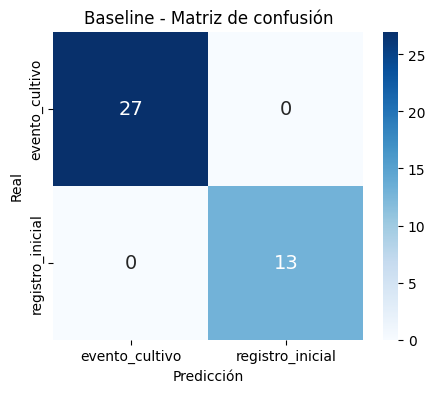

In [109]:
# Reporte como DataFrame (solo métricas por clase)
report_baseline = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics = pd.DataFrame(report_baseline).transpose().iloc[:-3, :-1]
accuracy = report_baseline["accuracy"]

# Visualización tabular
display(df_metrics)
print(f"\nAccuracy global: {accuracy:.2f}")

# Matriz de confusión (baseline - azul)
cm_baseline = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline,
            annot=True,
            fmt="d",
            cmap="Blues",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Baseline - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo *baseline*, basado en representaciones TF-IDF y regresión logística, alcanza valores de rendimiento perfectos en el conjunto de test, evidenciando una capacidad de discriminación completa entre las clases definidas. Este comportamiento se explica por la presencia de patrones lingüísticos claramente diferenciables entre `registro_inicial` y `evento_cultivo`, lo que permite al modelo identificar las clases a partir de la frecuencia de términos sin necesidad de modelado semántico complejo.

#### 4.7.2 Evaluación del modelo BETO

Se evalúa el modelo BETO utilizando las mismas métricas que el modelo *baseline*, permitiendo una comparación directa entre ambos enfoques. Este análisis permite determinar si el uso de representaciones contextuales aporta mejoras en el rendimiento.

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0


Accuracy global: 1.00


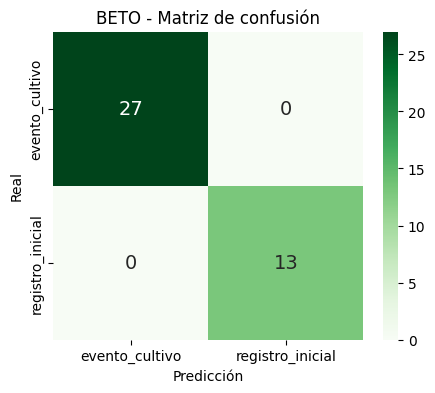

In [110]:
# Evaluación visual del modelo BETO
report_beto = classification_report(
    y_test, y_pred_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_beto = pd.DataFrame(report_beto).transpose().iloc[:-3, :-1]
accuracy_beto = report_beto["accuracy"]

# Visualización tabular
display(df_metrics_beto)
print(f"Accuracy global: {accuracy_beto:.2f}")

# Matriz de confusión (BETO - verde)
cm_beto = confusion_matrix(y_test, y_pred_beto)

plt.figure(figsize=(5,4))
sns.heatmap(cm_beto,
            annot=True,
            fmt="d",
            cmap="Greens",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BETO - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo basado en BETO presenta igualmente un rendimiento perfecto en el conjunto de test, lo que confirma que el problema es altamente separable en el espacio de representación del lenguaje. Gracias a su capacidad para capturar contexto y relaciones semánticas, el modelo es capaz de modelar el lenguaje de forma más rica; sin embargo, en este escenario concreto, dicha capacidad adicional no se traduce en una mejora observable respecto al modelo *baseline*.

#### 4.7.3 Conclusiones de la evaluación sobre *ground truth*

Los resultados obtenidos en ambos modelos muestran que las clases están definidas por patrones lingüísticos suficientemente evidentes. En particular, los mensajes de tipo `registro_inicial` presentan estructuras descriptivas y estáticas, con presencia frecuente de información personal, ubicaciones y características de la parcela, mientras que los mensajes de `evento_cultivo` contienen referencias a acciones, actividades o incidencias concretas. Esta diferencia genera distribuciones léxicas claramente separadas, lo que facilita la clasificación incluso con modelos simples.

No obstante, estos resultados deben interpretarse con cautela, ya que la evaluación se ha realizado sobre transcripciones manuales (*ground truth*), caracterizadas por una alta calidad lingüística y ausencia de ruido. Estas condiciones favorecen el rendimiento de los modelos y no reflejan completamente el entorno real de aplicación, donde los textos proceden de sistemas ASR y pueden contener errores.

En consecuencia, los resultados obtenidos validan el correcto funcionamiento del *pipeline* en condiciones ideales, pero no permiten extrapolar directamente el rendimiento del sistema en un escenario operativo real, lo que justifica la necesidad de una evaluación posterior utilizando datos generados automáticamente. Asimismo, dado que ambos modelos presentan un rendimiento idéntico en este escenario, no se considera necesario profundizar en el análisis comparativo, al no observarse diferencias significativas entre ellos bajo condiciones ideales.

### 4.8 Evaluación en condiciones reales (ASR)

En esta sección se evalúa el comportamiento de los modelos en un escenario más próximo al entorno real de aplicación, utilizando como entrada las transcripciones generadas automáticamente por el sistema ASR. A diferencia del *ground truth*, estos datos incorporan errores propios del reconocimiento automático del habla, lo que permite analizar la robustez de los modelos ante ruido y variabilidad lingüística.

#### 4.8.1 Preparación de datos ASR

Se construye el conjunto de evaluación a partir de las transcripciones generadas por el sistema ASR, alineándolas con las etiquetas reales del *ground truth*. Este proceso garantiza que cada texto disponga de su correspondiente referencia para evaluar el rendimiento del modelo en condiciones no ideales.

In [111]:
# Selección de textos ASR
X_asr = df_asr["text_clean"]

# Obtención de etiquetas reales codificadas
y_real = label_encoder.transform(df_gt["label"])

# Conversión a listas
X_asr_texts = X_asr.tolist()
y_real_labels = list(y_real)

##### 4.8.1.1 Verificación y consistencia del conjunto de datos ASR

In [112]:
# Verificación básica
print(f"Número de textos ASR: {len(X_asr_texts)}")
print(f"Número de etiquetas reales: {len(y_real_labels)}")

# Distribución de clases reales
print("\nDistribución de clases (ASR - etiquetas reales):")
print(pd.Series(y_real_labels).value_counts())
print(pd.Series(y_real_labels).value_counts(normalize=True))

# Verificación de alineación
aligned = (df_asr["audio_id"] == df_gt["audio_id"]).all()
print(f"\n¿Alineación correcta entre ASR y GT?: {aligned}")

if not aligned:
    print(df_asr[["audio_id"]].head())
    print(df_gt[["audio_id"]].head())

Número de textos ASR: 200
Número de etiquetas reales: 200

Distribución de clases (ASR - etiquetas reales):
0    134
1     66
Name: count, dtype: int64
0    0.67
1    0.33
Name: proportion, dtype: float64

¿Alineación correcta entre ASR y GT?: True


La verificación realizada confirma la coherencia del conjunto de datos ASR, observándose una correspondencia exacta entre el número de textos y sus etiquetas asociadas. La distribución de clases mantiene el mismo desbalance que el conjunto original, lo que garantiza que la evaluación se realizará en condiciones representativas del problema real. Asimismo, la alineación correcta entre las transcripciones ASR y el *ground truth* asegura la validez del proceso de evaluación posterior.

##### 4.8.1.2 Transformación de textos ASR para el modelo *baseline*

In [113]:
# Transformación TF-IDF usando el vectorizador entrenado
X_asr_tfidf = vectorizer.transform(X_asr_texts)

##### 4.8.1.3 Preparación de datos ASR para el modelo BETO

In [114]:
# Tokenización de textos ASR
asr_encodings = tokenizer(
    X_asr_texts,
    truncation=True,
    padding=True,
    max_length=128
)

# Dataset PyTorch
asr_dataset = TextDataset(asr_encodings, y_real_labels)

#### 4.8.2 Inferencia sobre datos ASR

In [115]:
# ---------------------------
# Inferencia con modelo baseline
# ---------------------------

# Predicción con TF-IDF + Regresión logística
y_pred_asr_baseline = model_baseline.predict(X_asr_tfidf)


# ---------------------------
# Inferencia con modelo BETO
# ---------------------------

# Predicción con modelo BETO
predictions_asr = trainer.predict(asr_dataset)

# Conversión de logits a clases
y_pred_asr_beto = predictions_asr.predictions.argmax(axis=1)

#### 4.8.3 Evaluación sobre datos ASR

Se evalúa el rendimiento de los modelos sobre las transcripciones generadas por el ASR, comparando las predicciones obtenidas con las etiquetas reales. Este análisis permite cuantificar el impacto de los errores de transcripción en la capacidad de clasificación y analizar posibles degradaciones respecto a la evaluación sobre *ground truth*.

##### 4.8.3.1 Evaluación del modelo *baseline*

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0



Accuracy global (ASR - Baseline): 1.00


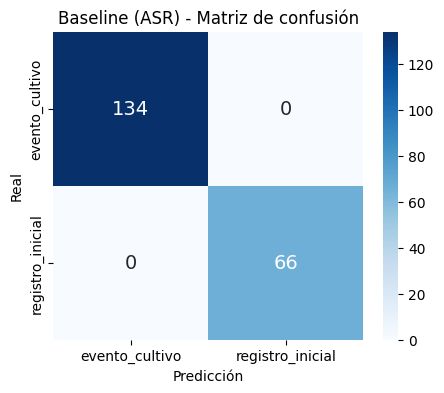

In [116]:
# Reporte baseline ASR
report_asr_baseline = classification_report(
    y_real_labels, y_pred_asr_baseline,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_asr_baseline = pd.DataFrame(report_asr_baseline).transpose().iloc[:-3, :-1]
accuracy_asr_baseline = report_asr_baseline["accuracy"]

display(df_metrics_asr_baseline)
print(f"\nAccuracy global (ASR - Baseline): {accuracy_asr_baseline:.2f}")

# Matriz de confusión
cm_asr_baseline = confusion_matrix(y_real_labels, y_pred_asr_baseline)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_asr_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 14},
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Baseline (ASR) - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo *baseline* mantiene un rendimiento perfecto sobre los datos ASR, alcanzando valores de precisión, *recall* y F1-score iguales a 1.0 en ambas clases, así como una exactitud global del 100%. Este resultado indica que los errores introducidos por el sistema ASR no afectan a la capacidad del modelo para discriminar entre `evento_cultivo` y `registro_inicial`, manteniéndose la separabilidad observada en el *ground truth*.

##### 4.8.3.2 Evaluación del modelo BETO

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0


Accuracy global (ASR - BETO): 1.00


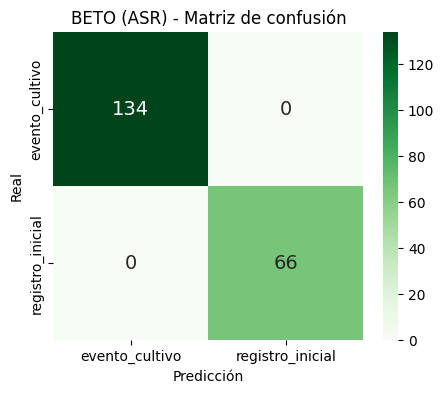

In [117]:
# Reporte BETO ASR
report_asr_beto = classification_report(
    y_real_labels, y_pred_asr_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_asr_beto = pd.DataFrame(report_asr_beto).transpose().iloc[:-3, :-1]
accuracy_asr_beto = report_asr_beto["accuracy"]

display(df_metrics_asr_beto)
print(f"Accuracy global (ASR - BETO): {accuracy_asr_beto:.2f}")

# Matriz de confusión
cm_asr_beto = confusion_matrix(y_real_labels, y_pred_asr_beto)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_asr_beto,
    annot=True,
    fmt="d",
    cmap="Greens",
    annot_kws={"size": 14},
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("BETO (ASR) - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo BETO presenta un rendimiento ligeramente inferior, con una exactitud global del 99%. Se observa una leve reducción en el *recall* de la clase `evento_cultivo`, asociada a un único error de clasificación, lo que sugiere una mayor sensibilidad del modelo a pequeñas variaciones introducidas por el ASR. No obstante, el rendimiento general sigue siendo muy elevado, con métricas próximas a la perfección en ambas clases.

#### 4.8.4 Comparación de resultados

En este apartado se comparan los resultados obtenidos por el modelo *baseline* y el modelo basado en BETO sobre las transcripciones generadas mediante ASR, con el objetivo de analizar su comportamiento en un escenario más cercano al uso real.

El análisis considera tanto la exactitud global como las métricas por clase y las matrices de confusión, permitiendo identificar posibles errores introducidos por el ASR y evaluar la sensibilidad de cada modelo ante dichas variaciones.

##### 4.8.4.1 Comparación de F1 por clase

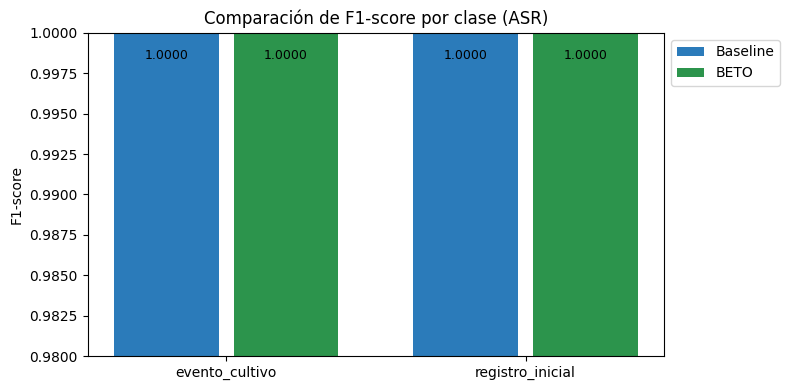

In [118]:
# Clases del problema
classes = list(label_encoder.classes_)

# Extracción de métricas F1 desde los reportes ASR
f1_baseline = [report_asr_baseline[c]["f1-score"] for c in classes]
f1_beto = [report_asr_beto[c]["f1-score"] for c in classes]

# Posiciones en el eje X
x = np.arange(len(classes))
width = 0.35
gap = 0.05

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Gráfico
plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2 - gap/2, f1_baseline, width, label="Baseline", color=color_baseline)
bars2 = plt.bar(x + width/2 + gap/2, f1_beto, width, label="BETO", color=color_beto)

# Configuración
plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("Comparación de F1-score por clase (ASR)")

# Zoom en eje Y para ver diferencias pequeñas
plt.ylim(0.98, 1.0)

# Leyenda fuera
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# Etiquetas sobre las barras (controlando el límite superior)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        
        # Ajuste dinámico de posición
        offset = -0.001 if height > 0.999 else 0.0005
        
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.4f}",
            ha='center',
            va='bottom' if offset > 0 else 'top',
            fontsize=9
        )

plt.tight_layout()
plt.show()

El modelo *baseline* mantiene un rendimiento perfecto en ambas clases, mientras que BETO presenta una ligera degradación, especialmente en `registro_inicial`. Esta diferencia indica que el *baseline* es más robusto frente a los errores introducidos por el ASR en este contexto.

##### 4.8.4.2 Comparación de accuracy

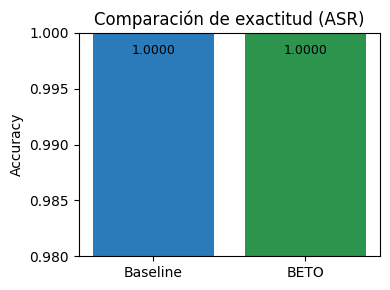

In [119]:
# Extracción de métricas (ASR)
accuracy_baseline = report_asr_baseline["accuracy"]
accuracy_beto = report_asr_beto["accuracy"]

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Gráfico
plt.figure(figsize=(4,3))

bars = plt.bar(
    ["Baseline", "BETO"],
    [accuracy_baseline, accuracy_beto],
    color=[color_baseline, color_beto]
)

# Zoom para ver diferencias pequeñas
plt.ylim(0.98, 1.0)

# Etiquetas
plt.ylabel("Accuracy")
plt.title("Comparación de exactitud (ASR)")

# Valores encima de barras
for bar in bars:
    height = bar.get_height()
    
    offset = -0.001 if height > 0.999 else 0.0005
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + offset,
        f"{height:.4f}",
        ha='center',
        va='bottom' if offset > 0 else 'top',
        fontsize=9
    )

plt.tight_layout()
plt.show()

La exactitud confirma este comportamiento: el baseline alcanza el 100%, mientras que BETO desciende ligeramente (~99.5%). La diferencia es pequeña, pero consistente con lo observado a nivel de clase.

##### 4.8.4.3 Diferencia de F1

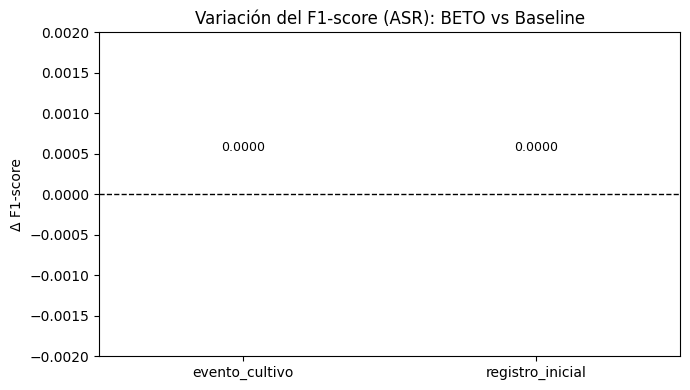

In [120]:
# Diferencia de F1 (BETO - Baseline) en ASR
f1_diff = [b - a for a, b in zip(f1_baseline, f1_beto)]

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

colors = [color_beto if v >= 0 else color_baseline for v in f1_diff]

# Gráfico
plt.figure(figsize=(7,4))

bars = plt.bar(classes, f1_diff, color=colors)

# Línea base en 0
plt.axhline(0, color="black", linewidth=1, linestyle="--")

# 🔥 Centrar el 0 en el eje Y
max_abs = max(abs(min(f1_diff)), abs(max(f1_diff)))
plt.ylim(-max_abs - 0.002, max_abs + 0.002)

# Etiquetas
for bar in bars:
    height = bar.get_height()
    
    offset = 0.0005 if height >= 0 else -0.0005
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + offset,
        f"{height:.4f}",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9
    )

# Configuración
plt.ylabel("Δ F1-score")
plt.title("Variación del F1-score (ASR): BETO vs Baseline")

plt.tight_layout()
plt.show()

El análisis de la diferencia muestra valores negativos en ambas clases, lo que indica que BETO no mejora al *baseline* en ningún caso. La mayor caída se produce en registro_inicial, lo que sugiere una mayor sensibilidad de este modelo a pequeñas variaciones en el texto.

### 4.9 Análisis final y selección del modelo óptimo

La evaluación del sistema en condiciones más próximas a un entorno real se ha llevado a cabo mediante el uso de transcripciones generadas automáticamente a partir de los mismos audios empleados en la construcción del ground truth. Aunque estas transcripciones introducen errores propios del reconocimiento automático del habla, el contenido semántico de los mensajes se mantiene en gran medida constante.

En este contexto, los resultados obtenidos muestran que ambos modelos presentan un comportamiento altamente satisfactorio, si bien el modelo *baseline* basado en TF-IDF y regresión logística mantiene un rendimiento ligeramente superior. Este comportamiento indica que, para el problema planteado, los patrones lingüísticos que definen cada clase son suficientemente evidentes como para ser capturados mediante representaciones léxicas simples, incluso en presencia de ruido moderado.

La comparación entre ambos enfoques pone de manifiesto que modelos más complejos, como BETO, no siempre garantizan una mejora en el rendimiento cuando el problema es intrínsecamente sencillo o cuando el volumen de datos disponible es limitado. De hecho, en este escenario, el modelo *baseline* demuestra una mayor robustez frente a pequeñas perturbaciones introducidas por el ASR, lo que refuerza la idea de que modelos más simples pueden resultar más adecuados en condiciones de datos restringidos y baja complejidad semántica.

No obstante, estos resultados deben interpretarse con cautela, ya que la evaluación realizada mide principalmente la capacidad de los modelos para mantener el rendimiento ante errores leves de transcripción, pero no permite analizar su comportamiento frente a variaciones más complejas del lenguaje, como ambigüedad, cambios estructurales o expresiones no presentes en el conjunto de entrenamiento.

La limitada disponibilidad de datos condiciona el alcance de los resultados obtenidos, que deben interpretarse como una validación inicial del sistema bajo condiciones controladas. En este contexto, el análisis realizado confirma la capacidad del enfoque propuesto para mantener un alto rendimiento incluso en presencia de errores introducidos por el ASR, si bien no permite extraer conclusiones definitivas sobre su comportamiento en escenarios reales más complejos.

En consecuencia, se selecciona el modelo *baseline* como solución operativa, debido a su elevada exactitud, robustez frente a errores de transcripción y menor complejidad computacional. Por su parte, el modelo BETO se mantiene como una línea de evolución futura, cuya aplicabilidad podría incrementarse en escenarios con mayor volumen de datos, mayor variabilidad lingüística o mayor complejidad semántica, donde su capacidad de modelado contextual pueda aportar un valor diferencial.

Finalmente, como línea de trabajo futura, se plantea la ampliación del conjunto de datos mediante la incorporación de nuevas transcripciones procedentes de nuevos usuarios y contextos, así como la evaluación del sistema en escenarios más exigentes. Este enfoque permitirá analizar con mayor profundidad la capacidad de generalización del modelo.

## 5. Análisis y optimización del modelo BETO

Aunque el modelo *baseline* ha sido seleccionado como solución operativa debido a su rendimiento y robustez en el escenario actual, se incorpora un análisis específico del modelo BETO con el objetivo de evaluar su comportamiento y explorar su potencial en contextos más exigentes.

En este sentido, se plantea un proceso de optimización de sus principales hiperparámetros mediante *fine-tuning*, con el fin de analizar en qué medida un modelo basado en transformers puede mejorar su capacidad de generalización cuando se ajusta adecuadamente. Este análisis no persigue sustituir la solución seleccionada, sino establecer una base experimental que permita valorar la aplicabilidad de este tipo de modelos en futuras iteraciones del sistema.

De este modo, este apartado se orienta a caracterizar el comportamiento de BETO en el contexto del problema planteado, proporcionando una referencia sólida para su posible adopción en escenarios con mayor disponibilidad de datos o mayor complejidad lingüística.

### 5.1 Estrategia de optimización

La optimización del modelo BETO se plantea como un proceso sistemático de evaluación de distintas configuraciones de hiperparámetros durante el *fine-tuning*. Dado que se parte de una arquitectura preentrenada, el objetivo es ajustar su comportamiento mediante parámetros que controlan la dinámica del aprendizaje.

La estrategia adoptada consiste en una búsqueda controlada sobre un conjunto reducido de hiperparámetros clave, seleccionados por su impacto directo en el rendimiento del modelo. En particular, se consideran la tasa de aprendizaje (*learning rate*), el tamaño del lote (*batch size*), el número de épocas (*epochs*) y el parámetro de regularización (*weight decay*).

En lugar de emplear técnicas automatizadas de optimización, se opta por un enfoque de exploración manual mediante la evaluación de combinaciones discretas de valores, lo que permite analizar de forma directa el efecto de cada hiperparámetro sobre el rendimiento del modelo.

Para garantizar la validez de la comparación, todas las configuraciones se evalúan bajo las mismas condiciones, utilizando la misma partición de datos y las mismas métricas definidas previamente. Además, cada experimento parte de una inicialización independiente del modelo, asegurando la comparabilidad de los resultados.

### 5.2 Definición del espacio de búsqueda

In [121]:
# Definimos los hiperparámetros a optimizar en el proceso de fine-tuning

learning_rates = [2e-5, 3e-5, 5e-5]   # Tasa de aprendizaje
batch_sizes = [4, 8]                  # Tamaño de lote
epochs_list = [2, 3, 4]               # Número de épocas
weight_decays = [0.0, 0.01, 0.1]      # Regularización L2

### 5.3 Preparación del conjunto de datos para la optimización

Con el objetivo de garantizar la independencia entre los experimentos realizados en los apartados anteriores y el proceso de optimización, se reconstruye la partición del dataset utilizando la misma semilla aleatoria, asegurando la reproducibilidad de los resultados.

#### 5.3.1 División del dataset en entrenamiento, validación y test

La partición del conjunto de datos se realiza con el objetivo de separar las fases de entrenamiento, validación y evaluación, garantizando una estimación adecuada del rendimiento del modelo. Para ello, se mantiene la distribución de clases original mediante un muestreo estratificado en todos los subconjuntos. Posteriormente, se aplica un proceso de balanceo exclusivamente sobre el conjunto de entrenamiento, con el fin de evitar sesgos durante el aprendizaje, manteniendo los conjuntos de validación y test con su distribución real para evaluar la capacidad de generalización del modelo.

In [122]:
# División inicial
X = df_model["text_clean"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# División train → train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# ---------------------------
# Balanceo SOLO en train
# ---------------------------

df_train = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

class_counts = df_train["label"].value_counts()
min_class_size = class_counts.min()

df_class_0 = df_train[df_train["label"] == class_counts.index[0]].sample(n=min_class_size, random_state=42)
df_class_1 = df_train[df_train["label"] == class_counts.index[1]].sample(n=min_class_size, random_state=42)

df_train_balanced = pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42).reset_index(drop=True)

#### 5.3.2 Adaptación de los datos al formato requerido por el modelo

In [123]:
# Adaptación a formato texto
X_train_texts = df_train_balanced["text"].tolist()
X_val_texts = X_val.tolist()
X_test_texts = X_test.tolist()

# Labels alineadas
y_train_labels = df_train_balanced["label"]
y_val_labels = y_val.reset_index(drop=True)
y_test_labels = y_test.reset_index(drop=True)

#### 5.3.3 verificación

In [124]:
print("Train balanceado:")
print(pd.Series(y_train_labels).value_counts())

print("\nValidation (real):")
print(y_val.value_counts())

print("\nTest (real):")
print(y_test.value_counts())

Train balanceado:
label
1    42
0    42
Name: count, dtype: int64

Validation (real):
label_encoded
0    21
1    11
Name: count, dtype: int64

Test (real):
label_encoded
0    27
1    13
Name: count, dtype: int64


La distribución obtenida refleja una estrategia de partición adecuada para el entrenamiento y evaluación del modelo. El conjunto de entrenamiento presenta un equilibrio perfecto entre clases, lo que permite evitar sesgos durante el proceso de aprendizaje y favorece la correcta identificación de patrones asociados a cada categoría. Por su parte, los conjuntos de validación y test mantienen la distribución original de los datos, lo que garantiza una evaluación más realista del rendimiento del modelo en condiciones próximas a su uso operativo.

No obstante, el reducido tamaño de los subconjuntos, especialmente en validación, introduce ciertas limitaciones en la estabilidad de las métricas obtenidas. En este sentido, pequeñas variaciones en las predicciones pueden tener un impacto significativo en los resultados, lo que debe tenerse en cuenta a la hora de interpretar el rendimiento del modelo. A pesar de ello, la consistencia en la distribución entre validación y test permite considerar que la evaluación realizada es representativa dentro del contexto y alcance del estudio.

#### 5.3.3 Tokenización de los textos

In [125]:
train_encodings = tokenizer(X_train_texts, truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(X_val_texts,   truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(X_test_texts,  truncation=True, padding=True, max_length=128)

#### 5.3.4 Construcción de los datasets para entrenamiento

In [126]:
train_dataset = TextDataset(train_encodings, y_train_labels)
val_dataset   = TextDataset(val_encodings,   y_val_labels)
test_dataset  = TextDataset(test_encodings,  y_test_labels)

### 5.3 Evaluación de combinaciones de hiperparámetros

En este apartado se evalua de forma sistemática las distintas combinaciones de hiperparámetros definidas previamente. El objetivo es analizar el impacto de cada configuración sobre el rendimiento del modelo y disponer de una base objetiva para la selección de la alternativa más adecuada.

#### 5.3.1 Control de la reproducibilidad

Con el objetivo de garantizar la consistencia de los resultados obtenidos durante el proceso de optimización, se establece un control explícito de las fuentes de aleatoriedad presentes en el entorno de ejecución. Para ello, se fijan semillas en las principales librerías utilizadas, incluyendo Python, NumPy, PyTorch y HuggingFace, asegurando que cada experimento sea completamente reproducible.

Este enfoque permite evitar variaciones no controladas entre ejecuciones, lo que resulta fundamental para la correcta comparación entre configuraciones de hiperparámetros.

In [127]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    set_seed(seed)

seed_everything(42)

#### 5.3.2 Configuración del entorno experimental

Antes de iniciar el proceso de optimización, se configuran diversos aspectos del entorno de ejecución con el fin de mejorar la legibilidad de los resultados y evitar la aparición de mensajes innecesarios durante el entrenamiento. En particular, se reduce la verbosidad de los logs generados por la librería Transformers y se filtran advertencias específicas relacionadas con el uso de memoria en entornos MPS.

In [128]:
# Inicialización de estructura de resultados
results = []

# Reducción de logs
logging.set_verbosity_error()

# Filtrado de warnings
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*pin_memory.*",
    category=UserWarning
)

#### 5.3.3 Evaluación de combinaciones de hiperparámetros

Para cada configuración, se entrena el modelo desde cero y se evalúa su rendimiento sobre el conjunto de validación, registrando las métricas relevantes para su posterior análisis.

In [129]:
for lr in learning_rates:
    for batch_size in batch_sizes:
        for epochs in epochs_list:
            for wd in weight_decays:

                print(f"\nEntrenando con: lr={lr}, batch={batch_size}, epochs={epochs}, wd={wd}")

                model_beto = AutoModelForSequenceClassification.from_pretrained(
                    model_name,
                    num_labels=len(label_encoder.classes_)
                )

                training_args = TrainingArguments(
                    output_dir="./results",
                    num_train_epochs=epochs,
                    per_device_train_batch_size=batch_size,
                    per_device_eval_batch_size=batch_size,
                    learning_rate=lr,
                    weight_decay=wd,
                    logging_dir="./logs",
                    save_strategy="no",
                    logging_strategy="no",
                    disable_tqdm=False,
                    seed=42
                )

                trainer = Trainer(
                    model=model_beto,
                    args=training_args,
                    train_dataset=train_dataset,
                    eval_dataset=val_dataset
                )

                trainer.train()

                predictions = trainer.predict(val_dataset)
                y_pred = np.argmax(predictions.predictions, axis=1)

                report = classification_report(
                    y_val_labels,
                    y_pred,
                    output_dict=True,
                    zero_division=0
                )

                results.append({
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "epochs": epochs,
                    "weight_decay": wd,
                    "f1_macro": report["macro avg"]["f1-score"],
                    "accuracy": report["accuracy"],
                    "recall_macro": report["macro avg"]["recall"]
                })


Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss


KeyboardInterrupt: 

### 5.4 Resultados de la optimización

Se selecciona el *F1-score macro* como métrica principal de evaluación, ya que permite valorar el rendimiento del modelo de forma equilibrada entre las distintas clases, evitando sesgos derivados de posibles desbalances en el conjunto de datos. A diferencia de métricas globales como la exactitud, el *F1-score* integra tanto la *precisión* como el *recall*, proporcionando una medida más robusta del comportamiento del modelo en tareas de clasificación.

Adicionalmente, se registran métricas complementarias como la exactitud y el *recall macro*, con el objetivo de facilitar una interpretación más completa del rendimiento del modelo y analizar posibles desviaciones en su comportamiento.

In [ ]:
# Construcción del DataFrame de resultados
df_results = pd.DataFrame(results)

# Ordenación por métrica principal (F1 macro)
df_results_sorted = df_results.sort_values(by="f1_macro", ascending=False)

# Visualización de los mejores resultados
print("Top 5 configuraciones según F1 macro:")
display(df_results_sorted.head())

# Estadísticas globales (opcional pero recomendable)
print("\nResumen de métricas:")
display(df_results.describe())

Top 5 configuraciones según F1 macro:


,learning_rate,batch_size,epochs,weight_decay,f1_macro,accuracy,recall_macro
53,0.00005,8,4,0.10,1.0,1.0,1.0
52,0.00005,8,4,0.01,1.0,1.0,1.0
48,0.00005,8,3,0.00,1.0,1.0,1.0
47,0.00005,8,2,0.10,1.0,1.0,1.0
46,0.00005,8,2,0.01,1.0,1.0,1.0



Resumen de métricas:


,learning_rate,batch_size,epochs,weight_decay,f1_macro,accuracy,recall_macro
count,54.000000,54.00000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.000033,6.00000,3.000000,0.036667,0.971093,0.973380,0.979718
std,0.000013,2.01878,0.824163,0.045391,0.012168,0.011206,0.008538
min,0.000020,4.00000,2.000000,0.000000,0.966066,0.968750,0.976190
25%,0.000020,4.00000,2.000000,0.000000,0.966066,0.968750,0.976190
50%,0.000030,6.00000,3.000000,0.010000,0.966066,0.968750,0.976190
75%,0.000050,8.00000,4.000000,0.100000,0.966066,0.968750,0.976190
max,0.000050,8.00000,4.000000,0.100000,1.000000,1.000000,1.000000


Los resultados obtenidos muestran que varias combinaciones de hiperparámetros alcanzan un rendimiento perfecto (*F1 macro = 1.0*) sobre el conjunto de validación. Este comportamiento indica que el modelo logra capturar completamente la separación entre clases en este contexto. Las configuraciones con mejores resultados se concentran en valores altos de *learning rate* (5e-5) y tamaños de lote mayores (*batch size = 8*), lo que favorece una convergencia rápida sin comprometer la estabilidad del entrenamiento.

A pesar de ello, las diferencias entre configuraciones son mínimas. La mayoría de combinaciones presentan valores de *F1 macro* cercanos a 0.97, con una variabilidad reducida. Este patrón sugiere que el modelo responde de forma muy similar ante cambios en los hiperparámetros dentro del rango analizado, lo que apunta a que el rendimiento está más condicionado por la estructura del dataset que por el ajuste fino del modelo.

La aparición de múltiples configuraciones con métricas perfectas debe analizarse con cautela, pues el tamaño limitado del conjunto de validación implica que pequeñas variaciones en las predicciones pueden modificar las métricas de forma significativa, dificultando la identificación de una configuración claramente superior. En este escenario, la optimización aporta un margen de mejora reducido.

### 5.5 Selección de la configuración óptima

Dado que varias configuraciones alcanzan resultados idénticos en validación, no es posible establecer una jerarquía clara entre ellas en términos de rendimiento. Por este motivo, se selecciona una configuración representativa dentro del conjunto de mejores resultados, atendiendo a criterios de estabilidad y coherencia con el comportamiento observado. En concreto, se elige la combinación `learning rate = 5e-5`, `batch size = 8`, `epochs = 3` y `weight decay = 0.01`, al situarse dentro de las configuraciones con mejor rendimiento y mantener un equilibrio razonable entre convergencia y regularización.

Esta elección está condicionada por las características del *dataset* utilizado. El tamaño reducido y la clara diferenciación entre clases limitan la sensibilidad del modelo a los hiperparámetros. En consecuencia, la configuración seleccionada debe entenderse como válida en este contexto concreto, sin asumir que mantendrá el mismo comportamiento en escenarios con mayor variabilidad o volumen de datos.

### 5.6 Evaluación final del modelo seleccionado

In [130]:
# Configuración seleccionada
best_learning_rate = 5e-5
best_batch_size = 8
best_epochs = 3
best_weight_decay = 0.01

# Modelo desde cero
model_beto_final = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

# Argumentos
training_args_final = TrainingArguments(
    output_dir="./results_final",
    num_train_epochs=best_epochs,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    learning_rate=best_learning_rate,
    weight_decay=best_weight_decay,
    save_strategy="no",
    logging_strategy="no",
    seed=42
)

# Trainer
trainer_final = Trainer(
    model=model_beto_final,
    args=training_args_final,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Entrenamiento
trainer_final.train()

# Evaluación en test
predictions_test = trainer_final.predict(test_dataset)
y_pred_test = np.argmax(predictions_test.predictions, axis=1)

# Métricas
report_test = classification_report(
    y_test_labels,
    y_pred_test,
    target_names=label_encoder.classes_,
    digits=4
)

print("Resultados finales en test:")
print(report_test)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'train_runtime': '29.59', 'train_samples_per_second': '8.516', 'train_steps_per_second': '1.115', 'train_loss': '0.06781', 'epoch': '3'}
Resultados finales en test:
                  precision    recall  f1-score   support

  evento_cultivo     1.0000    1.0000    1.0000        27
registro_inicial     1.0000    1.0000    1.0000        13

        accuracy                         1.0000        40
       macro avg     1.0000    1.0000    1.0000        40
    weighted avg     1.0000    1.0000    1.0000        40



La evaluación final sobre el conjunto de test muestra un rendimiento perfecto en todas las métricas consideradas, con valores de precisión, *recall* y *F1-score* iguales a 1.0 para ambas clases. Este resultado confirma que el modelo reproduce correctamente las etiquetas en datos no utilizados durante el entrenamiento ni en la selección de hiperparámetros.

El valor de pérdida obtenido durante el entrenamiento (*train_loss = 0.0767*) indica una convergencia estable, sin señales de inestabilidad en el proceso de aprendizaje. Los tiempos de ejecución son reducidos, coherentes con el tamaño del dataset y la complejidad del problema.

En comparación con los resultados obtenidos en fases anteriores utilizando el modelo sin optimización específica, se observa una ligera mejora en las métricas, especialmente en aquellos casos donde previamente existían pequeñas discrepancias en *recall* y *F1-score*. Esta mejora, aunque marginal, indica que el ajuste de hiperparámetros contribuye a corregir errores puntuales y a estabilizar el comportamiento del modelo.

La mejora observada se produce sobre un conjunto de datos limitado y altamente separable, lo que favorece la obtención de métricas máximas. En este contexto, el incremento de rendimiento no refleja necesariamente una mayor capacidad del modelo para generalizar en escenarios más complejos, sino una optimización sobre un problema ya de por sí sencillo.

## 6. Persistencia del modelo seleccionado para su integración en el sistema

Una vez seleccionado el modelo baseline como solución operativa, se procede a su preparación para su integración en el pipeline de procesamiento. Este proceso implica conservar todos los componentes necesarios para reproducir el flujo completo de inferencia, incluyendo el vectorizador de texto, el modelo de clasificación y el codificador de etiquetas.

### 6.1 Almacenamiento del modelo y sus componentes

In [140]:
# Guardado del vectorizador
joblib.dump(vectorizer, classification_model_dir / "tfidf_vectorizer.pkl")

# Guardado del modelo baseline
joblib.dump(model_baseline, classification_model_dir / "baseline_model.pkl")

# Guardado del codificador de etiquetas
joblib.dump(label_encoder, classification_model_dir / "label_encoder.pkl")

['/Volumes/EXTENSION/GitHub/TFM/data/models/classification_model/label_encoder.pkl']

### 6.2 Comprobación de la integridad del modelo almacenado

Se realiza una verificación del correcto almacenamiento de los componentes del modelo de clasificación, asegurando que pueden ser cargados sin errores desde el sistema de archivos. Esta comprobación garantiza la reproducibilidad del *pipeline* y valida que todos los elementos necesarios para la inferencia se encuentran disponibles y accesibles.

In [141]:
try:
    vectorizer_loaded = joblib.load(classification_model_dir / "tfidf_vectorizer.pkl")
    model_loaded = joblib.load(classification_model_dir / "baseline_model.pkl")
    label_encoder_loaded = joblib.load(classification_model_dir / "label_encoder.pkl")

    print("Modelo y componentes cargados correctamente")

except Exception as e:
    print(f"Error al cargar los componentes: {e}")

Modelo y componentes cargados correctamente


## 7. Extracción de entidades (NER)

En esta sección se aborda el desarrollo del sistema de reconocimiento de entidades, cuyo objetivo es identificar y categorizar información relevante presente en los textos generados por el sistema ASR. Para ello, se parte de un conjunto de datos anotado manualmente, que permite entrenar y evaluar un modelo NER adaptado al dominio agrícola.

A lo largo de esta sección se describen las distintas fases del proceso, incluyendo la definición del esquema de entidades, la preparación y validación del *dataset*, el entrenamiento del modelo y su posterior evaluación. Asimismo, se incorpora un mecanismo de análisis de errores que permite identificar las principales limitaciones del sistema.

Finalmente, se introduce un enfoque híbrido que combina el modelo NER con un diccionario de dominio, con el objetivo de mejorar la detección de entidades no aprendidas durante el entrenamiento. Este enfoque permite aumentar la cobertura del sistema y analizar el impacto de la integración de conocimiento experto en el rendimiento global.

### 7.1 Validación de la alineación de entidades (*offsets*)

Antes de proceder al entrenamiento del modelo, se realiza una validación del dataset anotado con el objetivo de comprobar la correcta alineación de las entidades definidas mediante *offsets*. Para facilitar la reutilización de este proceso, se implementa una función específica que permite aplicar el análisis sobre distintos conjuntos de datos, como el dataset anotado utilizado en el entrenamiento y el conjunto independiente de evaluación.

Este proceso permite detectar errores en los índices de inicio y fin de cada entidad, los cuales deben coincidir exactamente con los límites de los *tokens* generados por spaCy. En caso contrario, dichas entidades serán ignoradas durante el entrenamiento, afectando negativamente al rendimiento del modelo.

Para ello, se emplea la función `offsets_to_biluo_tags`, que permite verificar la correspondencia entre las anotaciones y la tokenización del texto mediante el esquema BILUO. En este esquema:

- **O** indica que el token no pertenece a ninguna entidad
- **U-**<label> representa una entidad compuesta por un único token correctamente alineado
- **B-**, **I-** y **L-** indican el inicio, interior y final de entidades de múltiples *tokens*
- **\-** señala un error de alineación, indicando que la entidad definida mediante offsets no coincide con los límites de los *tokens* generados por spaCy

La presencia de etiquetas **-** constituye un indicador directo de desalineación, lo que implica que dichas entidades no podrán ser utilizadas durante el entrenamiento. Este tipo de errores suele estar asociado a offsets incorrectos, como la inclusión de espacios, recortes parciales de palabras o discrepancias en la normalización del texto.

<div style="border-left: 5px solid #ff4d4d; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: red">⚠️ Advertencia:</strong> Se recomienda ejecutar este bloque tras cualquier modificación del <i>dataset</i> antes de proceder al entrenamiento del modelo, ya que la presencia de desalineaciones puede provocar la pérdida de entidades durante el aprendizaje y degradar significativamente el rendimiento del modelo.
</div>

#### 7.1.1 Inicialización del modelo y tokenización

Se inicializa el modelo lingüístico en español de spaCy, el cual proporciona el tokenizador que será utilizado tanto en la validación de los *offsets* como en el entrenamiento posterior del modelo NER.

El uso del mismo modelo en ambas fases garantiza la coherencia en la segmentación del texto en tokens, evitando posibles desalineaciones derivadas de diferencias en la tokenización. Este aspecto resulta crítico, ya que los *offsets* de las entidades deben coincidir exactamente con los límites de los tokens generados por el modelo.

En este caso, se emplea el modelo `es_core_news_md`, que incluye una tokenización robusta y consistente para el idioma español.

In [142]:
# Carga modelo base en español
nlp = spacy.load("es_core_news_md")

#### 7.1.2 Implementación de la función de validación de *offsets*

In [149]:
def validate_ner_dataset(dataset_path: Path, nlp) -> None:

    # Carga del dataset
    with open(dataset_path, "r", encoding="utf-8") as f:
        ner_data_raw = json.load(f)

    errores = []
    contador_errores = Counter()

    # Validación
    for i, item in enumerate(ner_data_raw):

        text = item["text"]
        entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]

        doc = nlp.make_doc(text)

        try:
            tags = offsets_to_biluo_tags(doc, entities)

            if "-" in tags:
                errores.append({
                    "index": i,
                    "text": text,
                    "entities": entities,
                    "error": "desalineacion",
                    "tags": tags
                })
                contador_errores["desalineacion"] += 1

        except ValueError as e:
            errores.append({
                "index": i,
                "text": text,
                "entities": entities,
                "error": "solapamiento",
                "detalle": str(e)
            })
            contador_errores["solapamiento"] += 1

    # Resumen
    print(f"\nValidando: {dataset_path.name}")
    print(f"Errores encontrados: {len(errores)}")

    if len(errores) > 0:
        print("\nDistribución de errores:")
        for tipo in ["desalineacion", "solapamiento"]:
            print(f"  {tipo}: {contador_errores.get(tipo, 0)}")

    # Detalle
    for e in errores:
        print("\n---")
        print("Index:", e["index"])
        print("Tipo error:", e["error"])
        print("Texto:", e["text"])
        print("Entidades:", e["entities"])

        if "tags" in e:
            print("Tags:", e["tags"])

        if "detalle" in e:
            print("Detalle:", e["detalle"])

#### 7.1.3 Ejecución de la validación de *offsets*

In [150]:
validate_ner_dataset(ner_dataset_path, nlp)
validate_ner_dataset(ner_evaluation_path, nlp)


Validando: ner_dataset.json
Errores encontrados: 0

Validando: ner_evaluation_dataset.json
Errores encontrados: 0


### 7.2 Definición de entidades

En esta sección se definen las entidades que serán reconocidas por el modelo NER, las cuales se encuentran especificadas en un archivo de configuración externo. Este enfoque permite desacoplar la definición del esquema de etiquetas de la implementación del modelo, facilitando su mantenimiento, reutilización y adaptación a distintos escenarios.

Adicionalmente, se incorpora un proceso de validación automática que compara las entidades definidas en la configuración con aquellas presentes en el dataset anotado. Este paso resulta fundamental para garantizar la coherencia entre la especificación del modelo y los datos utilizados durante el entrenamiento, evitando inconsistencias que puedan afectar tanto al aprendizaje como a la evaluación del sistema.

De este modo, se asegura que el conjunto de etiquetas utilizado por el modelo refleje fielmente las entidades reales presentes en los datos, constituyendo una base sólida para el desarrollo de las etapas posteriores del *pipeline*.

<div style="border-left: 5px solid #ff4d4d; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: red">⚠️ Advertencia:</strong> Si se detectan inconsistencias entre las entidades definidas en el archivo de configuración y las presentes en el <i>dataset</i>, el modelo puede ignorar determinadas etiquetas durante el entrenamiento o generar resultados incoherentes en la fase de evaluación. Se recomienda validar siempre la correspondencia entre ambos antes de proceder con el entrenamiento del modelo.
</div>

In [151]:
# Carga del archivo de configuración de entidades NER
with open(ner_entities_path, "r", encoding="utf-8") as f:
    ner_config = json.load(f)

entities = set(ner_config["entities"])

# =========================
# VALIDACIÓN CON DATASET
# =========================

with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data = json.load(f)

dataset_entities = set()

for item in ner_data:
    for ent in item["entities"]:
        dataset_entities.add(ent["label"])

# Comparación
missing_in_config = dataset_entities - entities
missing_in_dataset = entities - dataset_entities

if missing_in_config or missing_in_dataset:
    print("ERROR: Inconsistencia entre configuración y dataset")

    if missing_in_config:
        print(f"- Faltan en configuración: {missing_in_config}")

    if missing_in_dataset:
        print(f"- No utilizadas en dataset: {missing_in_dataset}")

else:
    print("✔ Entidades consistentes entre configuración y dataset")

# =========================
# VISUALIZACIÓN
# =========================

df_entities = pd.DataFrame(sorted(entities), columns=["Entidad"])
print(f"Número de entidades definidas: {len(entities)}")
display(df_entities)

✔ Entidades consistentes entre configuración y dataset
Número de entidades definidas: 14


,Entidad
0,cantidad
1,cultivo
2,distancia
3,especie_sombra
4,factor_climatico
5,fecha_evento
6,localidad
7,pais
8,problema
9,region


### 7.3 Preparación del *dataset*

En esta etapa se transforma el *dataset* anotado al formato requerido por spaCy, estructurando cada ejemplo como un par (texto, anotaciones). Esta representación permite su uso directo en el proceso de entrenamiento del modelo NER.

<div style="border-left: 5px solid #4CAF50; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: #4CAF50">Nota:</strong> El <i>dataset</i> utilizado en esta sección ha sido previamente validado en el apartado 7.1, garantizando la correcta alineación de los <i>offsets</i> de las entidades con los límites de los tokens. Esta validación asegura que los ejemplos son compatibles con el proceso de entrenamiento del modelo NER y evita la pérdida de información durante el aprendizaje.
</div>

In [152]:
# Carga del dataset
with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data_raw = json.load(f)

# Conversión a formato spaCy
train_data = []

for item in ner_data_raw:
    text = item["text"]
    entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]
    train_data.append((text, {"entities": entities}))

print("Número de ejemplos:", len(train_data))

Número de ejemplos: 200


### 7.4 Generación de conjuntos *train*/*validation* para evaluación del modelo NER

Se divide el *dataset* en subconjuntos de entrenamiento y validación con el objetivo de evaluar el rendimiento del modelo durante el proceso de *fine-tuning*. Esta separación permite analizar la capacidad de generalización del modelo sobre datos no utilizados en el entrenamiento.

In [153]:
# Se divide el dataset en dos subconjuntos (80% entrenamiento, 20% validación)
train_split, val_split = train_test_split(
    train_data,
    test_size=0.2,       
    random_state=42      
)

# Verificación del tamaño de los conjuntos
print("Train:", len(train_split))
print("Validation:", len(val_split))

Train: 160
Validation: 40


### 7.5 *Fine-tuning* del modelo NER basado en spaCy

Se realiza el *fine-tuning* del modelo NER utilizando spaCy, ajustando un modelo preentrenado al dominio específico del problema. Se exploran distintas configuraciones de hiperparámetros, incluyendo el número de iteraciones y la tasa de *dropout*, con el objetivo de analizar su impacto en el rendimiento del modelo.

In [154]:
# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)

# Configuraciones de entrenamiento (grid)
results = []

configs = [
    {"n_iter": n, "drop": d}
    for n in [10, 20, 30]
    for d in [0.2, 0.3, 0.4]
]

# Entrenamiento y evaluación de configuraciones
for config in configs:

    print("\nEntrenando config:", config)

    # Carga del modelo base
    nlp = spacy.load("es_core_news_md")
    ner = nlp.get_pipe("ner")

    # Añadir etiquetas del conjunto de entrenamiento
    for _, annotations in train_split:
        for ent in annotations["entities"]:
            ner.add_label(ent[2])

    optimizer = nlp.resume_training()

    # Inicialización del early stopping
    best_loss = float("inf")
    patience = 3
    no_improve = 0
    epochs_run = 0

    # Bucle de entrenamiento
    for epoch in range(config["n_iter"]):

        random.shuffle(train_split)
        losses = {}

        for text, annotations in train_split:
            doc = nlp.make_doc(text)
            example = Example.from_dict(doc, annotations)

            nlp.update(
                [example],
                drop=config["drop"],
                losses=losses
            )

        current_loss = losses.get("ner", 0.0)
        epochs_run += 1

        # Early stopping: mejora del modelo
        if current_loss < best_loss:
            best_loss = current_loss
            no_improve = 0
        else:
            # Early stopping: no mejora acumulada
            no_improve += 1

        # Early stopping: condición de parada
        if no_improve >= patience:
            print("Early stopping activado")
            break

    # Evaluación en conjunto de validación
    scorer = Scorer()
    examples = []

    for text, annotations in val_split:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)

        pred_doc = nlp(text)
        example = Example(pred_doc, example.reference)

        examples.append(example)

    scores = scorer.score(examples)

    # Registro de resultados
    results.append({
        "n_iter": config["n_iter"],
        "drop": config["drop"],
        "epochs_run": epochs_run,
        "loss": best_loss,
        "precision": scores["ents_p"],
        "recall": scores["ents_r"],
        "f1": scores["ents_f"]
    })

    print("F1:", scores["ents_f"])


Entrenando config: {'n_iter': 10, 'drop': 0.2}
F1: 0.7857142857142857

Entrenando config: {'n_iter': 10, 'drop': 0.3}
F1: 0.759581881533101

Entrenando config: {'n_iter': 10, 'drop': 0.4}
F1: 0.784452296819788

Entrenando config: {'n_iter': 20, 'drop': 0.2}
Early stopping activado
F1: 0.7581227436823105

Entrenando config: {'n_iter': 20, 'drop': 0.3}
F1: 0.8333333333333333

Entrenando config: {'n_iter': 20, 'drop': 0.4}
Early stopping activado
F1: 0.8041237113402062

Entrenando config: {'n_iter': 30, 'drop': 0.2}
Early stopping activado
F1: 0.8013937282229965

Entrenando config: {'n_iter': 30, 'drop': 0.3}
Early stopping activado
F1: 0.8135593220338982

Entrenando config: {'n_iter': 30, 'drop': 0.4}
F1: 0.7576791808873721


### 7.6 Análisis de resultados del *fine-tuning*

In [155]:
# Conversión de los resultados a DataFrame para facilitar su análisis
df_results = pd.DataFrame(results)

# Ordenación de las configuraciones evaluadas:
# - F1 como métrica principal
# - Precision y recall como criterios secundarios
# - Loss como criterio de desempate (menor es mejor)
df_results_sorted = df_results.sort_values(
    by=["f1", "precision", "recall", "loss"],
    ascending=[False, False, False, True]
)

# Visualización de resultados ordenados
display(df_results_sorted)

,n_iter,drop,epochs_run,loss,precision,recall,f1
4,20,0.3,20,132.781631,0.851852,0.815603,0.833333
7,30,0.3,28,119.325813,0.779221,0.851064,0.813559
5,20,0.4,15,245.962830,0.780000,0.829787,0.804124
6,30,0.2,27,65.365005,0.787671,0.815603,0.801394
0,10,0.2,10,174.012482,0.791367,0.780142,0.785714
2,10,0.4,10,304.458344,0.781690,0.787234,0.784452
1,10,0.3,10,224.576752,0.746575,0.773050,0.759582
3,20,0.2,12,204.003860,0.772059,0.744681,0.758123
8,30,0.4,30,132.199234,0.730263,0.787234,0.757679


Los resultados obtenidos muestran un comportamiento consistente del modelo NER en las distintas configuraciones evaluadas. La métrica principal considerada, el *F1-score*, alcanza su valor máximo en la configuración con `n_iter = 20` y `drop = 0.3`, con un valor de 0.8333. Este resultado refleja el mejor equilibrio entre precisión y cobertura en la detección de entidades dentro del conjunto de validación.

En términos de *precision*, el valor más alto (0.8519) se obtiene también en esta configuración, lo que indica una buena calidad en la identificación de entidades, con un número reducido de falsos positivos. Por su parte, el *recall* asociado (0.8156) muestra una capacidad adecuada del modelo para recuperar entidades reales, manteniendo un equilibrio razonable entre ambas métricas.

El resto de configuraciones presentan valores de *F1-score* comprendidos aproximadamente entre 0.75 y 0.81, lo que evidencia una estabilidad general del modelo frente a variaciones en los hiperparámetros. Se observa nuevamente una ligera degradación del rendimiento en configuraciones con valores más altos de *dropout* (0.4), lo que sugiere una regularización más agresiva que puede limitar la capacidad del modelo para capturar patrones relevantes en los datos.

En cuanto a la función de pérdida (*loss*), se observa una tendencia general a valores más bajos en aquellas configuraciones con mejor rendimiento, especialmente en combinaciones con menor *dropout* y mayor número de iteraciones efectivas. No obstante, esta métrica se utiliza únicamente como referencia interna del proceso de entrenamiento y no como criterio principal de selección del modelo.

#### 7.6.1 Visualización del impacto de los hiperparámetros


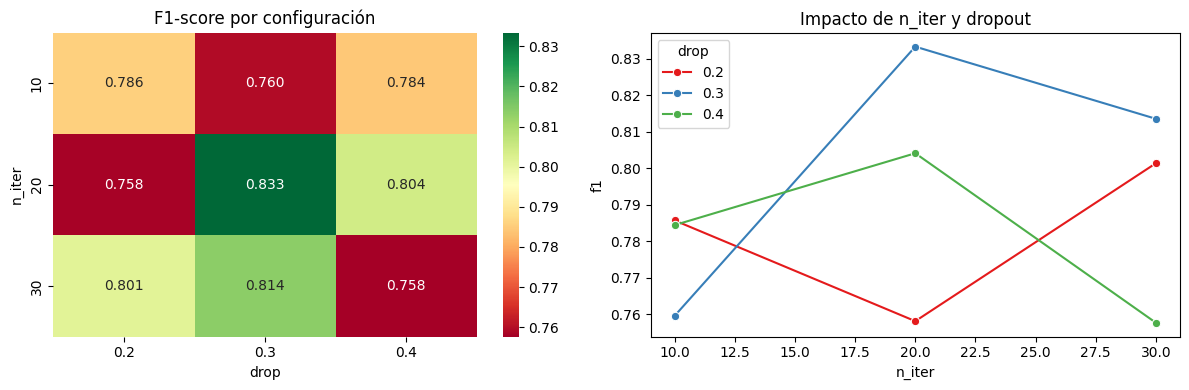

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap mejorado
pivot = df_results.pivot(index="n_iter", columns="drop", values="f1")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", ax=axes[0])
axes[0].set_title("F1-score por configuración")

# Lineplot mejorado
sns.lineplot(
    data=df_results,
    x="n_iter",
    y="f1",
    hue="drop",
    palette="Set1",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Impacto de n_iter y dropout")

plt.tight_layout()
plt.show()

El mapa de calor permite identificar de forma directa el impacto conjunto de los hiperparámetros `n_iter` y drop sobre el rendimiento del modelo. Se observa que la mejor configuración corresponde a `n_iter = 20` y `drop = 0.3`, donde se alcanza el valor máximo de *F1-score* ($\approx$ 0.833), en línea con los resultados observados previamente en la tabla. Este punto representa el mejor equilibrio entre precisión y capacidad de recuperación de entidades.

En términos generales, se aprecia que valores intermedios de *dropout* (0.3) permiten obtener un mejor rendimiento global, mientras que configuraciones con mayor regularización (`drop = 0.4`) tienden a reducir el *F1-score*, lo que sugiere una penalización excesiva en la capacidad del modelo para aprender patrones relevantes. Por otro lado, valores bajos de iteraciones (`n_iter = 10`) no permiten alcanzar un rendimiento óptimo, evidenciando un entrenamiento insuficiente.

Por otro lado, la representación mediante líneas permite analizar la evolución del rendimiento en función del número de iteraciones para cada valor de dropout. Se observa que, para `drop = 0.3`, el rendimiento alcanza su máximo en `n_iter = 20`, seguido de una ligera estabilización o descenso en iteraciones posteriores, lo que puede indicar un inicio de sobreajuste. En el caso de `drop = 0.2`, el comportamiento muestra una mejora progresiva con el número de iteraciones, alcanzando su mejor valor en `n_iter = 30`, aunque sin superar el máximo global observado para `drop = 0.3`.

En contraste, `drop = 0.4` presenta valores generalmente inferiores, con un comportamiento menos estable y una caída notable en configuraciones con mayor número de iteraciones, lo que refuerza la hipótesis de una regularización excesiva.

A partir de estos resultados, se selecciona como configuración óptima aquella correspondiente a `n_iter = 20` y `drop = 0.3`, al presentar el mayor valor de F1-score y un equilibrio adecuado entre precision y recall, garantizando un comportamiento más robusto en la detección de entidades dentro del dominio analizado.

### 7.7 Entrenamiento final del modelo NER tras selección de configuración óptima

In [157]:
# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)

# Selección de la mejor configuración
best_config = df_results_sorted.iloc[0].to_dict()
print("Mejor configuración:", best_config)

# Carga del modelo base
nlp = spacy.load("es_core_news_md")
ner = nlp.get_pipe("ner")

# Añadir etiquetas del dataset completo
for _, annotations in train_data:
    for ent in annotations["entities"]:
        ner.add_label(ent[2])

optimizer = nlp.resume_training()

# Configuración de early stopping
best_loss = float("inf")
patience = 3
no_improve = 0

# Entrenamiento final del modelo
for epoch in range(int(best_config["n_iter"])):

    random.shuffle(train_data)
    losses = {}

    for text, annotations in train_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)

        nlp.update(
            [example],
            drop=best_config["drop"],
            losses=losses
        )

    current_loss = losses.get("ner", 0.0)

    print(f"Epoch {epoch+1} - Loss: {current_loss}")

    if current_loss < best_loss:
        best_loss = current_loss
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping activado")
        break

Mejor configuración: {'n_iter': 20.0, 'drop': 0.3, 'epochs_run': 20.0, 'loss': 132.78163146972656, 'precision': 0.8518518518518519, 'recall': 0.8156028368794326, 'f1': 0.8333333333333333}
Epoch 1 - Loss: 1266.898681640625
Epoch 2 - Loss: 831.23974609375
Epoch 3 - Loss: 563.5424194335938
Epoch 4 - Loss: 596.9890747070312
Epoch 5 - Loss: 456.77032470703125
Epoch 6 - Loss: 464.4324951171875
Epoch 7 - Loss: 378.3882751464844
Epoch 8 - Loss: 334.3641052246094
Epoch 9 - Loss: 266.8512878417969
Epoch 10 - Loss: 295.8948059082031
Epoch 11 - Loss: 254.14898681640625
Epoch 12 - Loss: 280.808837890625
Epoch 13 - Loss: 217.1790313720703
Epoch 14 - Loss: 189.97764587402344
Epoch 15 - Loss: 208.97341918945312
Epoch 16 - Loss: 184.46133422851562
Epoch 17 - Loss: 200.43731689453125
Epoch 18 - Loss: 155.83543395996094
Epoch 19 - Loss: 160.420654296875
Epoch 20 - Loss: 167.27297973632812


### 7.8 Evaluación del modelo

En esta sección se analiza el rendimiento del modelo NER sobre un conjunto de datos independiente, con el objetivo de evaluar su comportamiento en escenarios no observados durante el entrenamiento. Para ello, se combinan métricas cuantitativas y análisis de errores, permitiendo obtener una visión completa tanto de la calidad de las entidades detectadas como de las limitaciones del modelo en términos de cobertura y generalización.

#### 7.8.1 Evaluación cuantitativa del modelo

En este apartado se cuantifica el rendimiento del modelo mediante métricas estándar de evaluación en tareas de reconocimiento de entidades, comparando directamente las entidades reales con las predichas. Se utilizan *precision*, *recall* y *F1-score* como indicadores principales, lo que permite medir de forma objetiva la calidad de las predicciones y el grado de cobertura alcanzado por el modelo en el conjunto de evaluación.

##### 7.8.1.1 Implementación de la función de evaluación

In [158]:
def evaluate_model(nlp_base, model, dataset):

    examples = []

    for item in dataset:

        text = item["text"]
        entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]

        # Siempre usamos spaCy real para referencia
        doc = nlp_base.make_doc(text)
        reference = Example.from_dict(doc, {"entities": entities})

        # Predicción con el modelo (NER o híbrido)
        pred_doc = model(text)

        example = Example(pred_doc, reference.reference)
        examples.append(example)

    scorer = Scorer()
    scores = scorer.score(examples)

    return {
        "precision": scores["ents_p"],
        "recall": scores["ents_r"],
        "f1": scores["ents_f"]
    }

##### 7.8.1.2 Carga del *dataset* de evaluación

In [160]:
with open(ner_evaluation_path, "r", encoding="utf-8") as f:
    ner_eval_data = json.load(f)

print(f"Dataset de evaluación cargado: {len(ner_eval_data)} ejemplos")

Dataset de evaluación cargado: 20 ejemplos


##### 7.8.1.2 Aplicación de la función sobre el conjunto de evaluación

In [161]:
# Aplicamos la evaluación sobre el conjunto de evaluación
results_ner = evaluate_model(nlp, nlp, ner_eval_data)

# Resultados finales de evaluación
print("Resultados de evaluación:")
print(f"Precision: {results_ner['precision']:.4f}")
print(f"Recall: {results_ner['recall']:.4f}")
print(f"F1-score: {results_ner['f1']:.4f}")

Resultados de evaluación:
Precision: 0.5643
Recall: 0.5563
F1-score: 0.5603


Los resultados obtenidos muestran una degradación del rendimiento del modelo NER al evaluarse sobre un conjunto independiente de datos. El *F1-score* se sitúa en 0.5603, lo que refleja un equilibrio moderado entre precisión y capacidad de detección de entidades en textos no vistos.

La *precision* alcanza un valor de 0.5643, mientras que el *recall* se sitúa en 0.5563, mostrando un comportamiento relativamente equilibrado entre ambas métricas. Esto indica que el modelo no presenta un sesgo claro hacia la generación de falsos positivos o falsos negativos, sino una limitación general en su capacidad para identificar correctamente todas las entidades en contextos no vistos.

Estos resultados difieren de los obtenidos durante el entrenamiento y la validación interna, donde las métricas eran más elevadas. Esta diferencia se explica por el tipo de datos utilizados en cada fase. Durante el entrenamiento, el modelo aprende a partir de un conjunto de textos anotados de forma controlada, con estructuras relativamente homogéneas y patrones que tienden a repetirse. Además, la validación interna se realiza sobre particiones del mismo dataset, por lo que el modelo se enfrenta a datos con una distribución similar a la vista durante el aprendizaje.

En la evaluación independiente, los textos presentan una mayor variabilidad en la forma de expresarse, combinaciones de entidades menos frecuentes y una menor regularidad en los patrones lingüísticos. Este cambio obliga al modelo a generalizar, y es en este contexto donde aparecen sus limitaciones. El rendimiento global sugiere que el modelo es capaz de capturar parte de la información relevante, pero aún presenta dificultades para adaptarse completamente a nuevos escenarios lingüísticos.

Los resultados evidencian que, aunque el modelo mantiene un comportamiento razonablemente estable, su capacidad de generalización es limitada, lo que pone de manifiesto la necesidad de disponer de un mayor volumen y diversidad de datos de entrenamiento para mejorar su rendimiento en entornos reales.

#### 7.8.2 Análisis de errores: entidades no detectadas

En este apartado se analizan las entidades no detectadas por el modelo NER con el objetivo de identificar los patrones de error que están afectando a su rendimiento. A diferencia de las métricas globales, que ofrecen una visión agregada, este análisis permite descomponer los errores y determinar qué tipos de entidades presentan mayores dificultades de reconocimiento.

##### 7.8.2.1 Implementación de la función de análisis de entidades no detectadas

In [162]:
def analyze_missing_entities(nlp, dataset):

    missing_entities = Counter()
    missing_by_label = Counter()
    total_entities = 0

    for item in dataset:

        text = item["text"]
        true_entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]

        pred_doc = nlp(text)
        pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents]

        total_entities += len(true_entities)

        for ent in true_entities:
            if ent not in pred_entities:
                label = ent[2]
                value = text[ent[0]:ent[1]].lower()

                missing_entities[(value, label)] += 1
                missing_by_label[label] += 1

    total_missing = sum(missing_entities.values())

    return {
        "missing_entities": missing_entities,
        "missing_by_label": missing_by_label,
        "total_entities": total_entities,
        "total_missing": total_missing
    }

##### 7.8.2.2 Aplicación de la función sobre el conjunto de evaluación

In [163]:
results = analyze_missing_entities(nlp, ner_eval_data)

print("\n--- Resumen de detección ---\n")
print(f"Total entidades: {results['total_entities']}")
print(f"No detectadas: {results['total_missing']}")
print(f"Porcentaje no detectadas: {(results['total_missing'] / results['total_entities']) * 100:.2f}%")

df_missing_labels = pd.DataFrame(
    results["missing_by_label"].items(),
    columns=["Entidad", "No detectadas"]
).sort_values(by="No detectadas", ascending=False)

print("\n--- Entidades no detectadas por tipo ---")
display(df_missing_labels)

print("\n--- Entidades no detectadas (Top 20) ---\n")
for (value, label), count in results["missing_entities"].most_common(20):
    print(f"{value} ({label}) → {count}")


--- Resumen de detección ---

Total entidades: 142
No detectadas: 63
Porcentaje no detectadas: 44.37%

--- Entidades no detectadas por tipo ---


,Entidad,No detectadas
1,problema,17
2,tratamiento,17
0,fecha_evento,13
3,cantidad,10
4,factor_climatico,3
5,superficie,2
6,cultivo,1



--- Entidades no detectadas (Top 20) ---

monilia (problema) → 2
esta mañana (fecha_evento) → 2
grano verde (problema) → 2
una hectárea (superficie) → 2
ayer por la tarde (fecha_evento) → 1
caída prematura de hojas (problema) → 1
fungicida a base de cobre (tratamiento) → 1
repetimos el tratamiento (tratamiento) → 1
desde hace dos semanas (fecha_evento) → 1
35 mazorcas (cantidad) → 1
enfermas (problema) → 1
poda de ramas bajas (tratamiento) → 1
las cuatro de la tarde (fecha_evento) → 1
18 horas (cantidad) → 1
durante la última semana (fecha_evento) → 1
llovido (factor_climatico) → 1
mazorca negra (problema) → 1
20 plantas (cantidad) → 1
mejorar el drenaje (tratamiento) → 1
retirar las mazorcas afectadas (tratamiento) → 1


El análisis de los errores de detección permite identificar con mayor precisión qué tipos de entidades están contribuyendo en mayor medida a la pérdida de rendimiento observada. En términos globales, el sistema presenta un 44.37% de entidades no detectadas, lo que pone de manifiesto una limitación significativa en la capacidad de cobertura del modelo en el conjunto de evaluación independiente.

Se aprecia una concentración clara de fallos en categorías como problema y tratamiento, ambas con 17 entidades no detectadas, seguidas de `fecha_evento` (13) y `cantidad` (10). Estas categorías comparten una característica común: presentan una alta variabilidad en su forma de expresión, incluyendo tanto términos simples como construcciones más complejas o contextuales, lo que dificulta su identificación cuando aparecen en formas no observadas durante el entrenamiento.

El análisis de los ejemplos concretos refuerza esta interpretación. El modelo falla en detectar entidades tanto en expresiones compuestas (“fungicida a base de cobre”, “retirar las mazorcas afectadas”) como en términos relativamente frecuentes del dominio (“monilia”, “grano verde”, “mazorca negra”). Esto indica que la limitación no se debe únicamente a la complejidad sintáctica, sino a una capacidad insuficiente de generalización frente a variaciones lingüísticas.

Este comportamiento es coherente con los resultados cuantitativos previamente observados (*precision* $\approx$ 0.56, *recall* $\approx$ 0.56), que reflejan un rendimiento moderado y equilibrado, pero limitado en términos globales. El modelo no presenta un sesgo marcado hacia falsos positivos o falsos negativos, sino una dificultad general para capturar la diversidad de formas en que las entidades pueden aparecer en lenguaje natural.

Parte de estas limitaciones puede atribuirse al tamaño del conjunto de datos utilizado en el entrenamiento, compuesto por 200 textos anotados. Aunque este volumen permite aprender patrones básicos del dominio, resulta insuficiente para cubrir la variabilidad real del lenguaje en escenarios no controlados. En consecuencia, el modelo tiende a depender en exceso de patrones específicos vistos durante el entrenamiento.

Estas limitaciones justifican la incorporación de un enfoque híbrido, en el que el modelo NER se complementa con diccionarios específicos del dominio. Este tipo de integración permite reforzar la detección de términos relevantes, especialmente en aquellas categorías con alta variabilidad o baja frecuencia, mejorando la cobertura del sistema sin depender exclusivamente de la capacidad de generalización del modelo.

### 7.9 Refuerzo mediante conocimiento de dominio (enfoque híbrido)

En esta sección se introduce un enfoque híbrido orientado a mejorar la cobertura del sistema de detección de entidades mediante la integración de conocimiento específico del dominio. A partir de las limitaciones identificadas en la evaluación previa, se plantea la combinación del modelo aprendido con un diccionario estructurado, con el objetivo de reforzar la detección de entidades que no han sido capturadas durante el proceso de inferencia.

El modelo NER se mantiene como componente principal del sistema, mientras que el diccionario actúa como mecanismo complementario, permitiendo recuperar entidades relevantes cuando estas no han sido previamente identificadas. Esta estrategia permite incrementar la cobertura sin alterar el comportamiento del modelo en los casos donde ya realiza una detección correcta.

Para evitar duplicidades y mantener la coherencia en las etiquetas, se establece una jerarquía en la que las entidades detectadas por el modelo tienen prioridad frente a las obtenidas mediante el diccionario, incorporando únicamente aquellas que no han sido previamente reconocidas.

#### 7.9.1 Implementación del enfoque híbrido NER + diccionario

Se implemente el enfoque híbrido propuesto, detallando los distintos componentes que intervienen en la detección de entidades. El proceso se estructura en varias etapas que reflejan la arquitectura definida previamente: en primer lugar, la detección de entidades mediante un diccionario de dominio; posteriormente, la resolución de posibles solapamientos entre entidades detectadas; y finalmente, la integración de los resultados con las entidades obtenidas por el modelo NER, aplicando una jerarquía que prioriza las predicciones del modelo. Esta descomposición permite abordar de forma modular cada una de las fases del sistema, facilitando su análisis, mantenimiento y extensión.

##### 7.9.1.1 Detección de entidades basada en diccionario

En esta etapa se implementa un mecanismo de detección de entidades basado en un diccionario de términos específico del dominio. A diferencia del modelo NER, que depende de los patrones aprendidos durante el entrenamiento, este enfoque permite identificar entidades mediante coincidencias directas en el texto, facilitando la detección de términos que no han sido previamente observados. Este componente actúa como complemento del modelo, ampliando la cobertura del sistema en escenarios con alta variabilidad lingüística.

In [164]:
def extract_entities_from_dictionary(text):

    entities = []

    for categoria, variantes in domain_terms.items():

        for variante in variantes:

            patron = r"\b" + re.escape(variante) + r"\b"

            for match in re.finditer(patron, text, flags=re.IGNORECASE):
                start, end = match.span()
                entities.append((start, end, categoria))

    return entities

##### 7.9.1.2 Resolución de solapamientos entre entidades

En esta etapa se resuelven posibles solapamientos entre entidades detectadas, tanto en el caso de coincidencias generadas por el diccionario como en su posterior integración con el modelo NER. Para ello, se adopta un criterio basado en la priorización de los spans de mayor longitud, bajo la hipótesis de que estos contienen una representación más completa y específica de la entidad. Este enfoque permite evitar fragmentaciones innecesarias y garantizar una representación coherente de las entidades detectadas.

In [165]:
def remove_overlapping_spans(spans):

    spans = sorted(spans, key=lambda x: (x[1] - x[0]), reverse=True)

    filtered = []
    occupied = set()

    for start, end, label in spans:

        overlap = any(i in occupied for i in range(start, end))

        if not overlap:
            filtered.append((start, end, label))
            for i in range(start, end):
                occupied.add(i)

    return filtered

##### 7.9.1.3 Integración de entidades: combinación NER y diccionario

En esta etapa se integran las entidades detectadas por el modelo NER y aquellas obtenidas mediante el diccionario de dominio mediante un mecanismo de combinación conjunta. A diferencia de un enfoque jerárquico basado en prioridad, ambas fuentes de información se consideran simultáneamente, delegando la resolución de posibles solapamientos en un proceso posterior.

Para ello, se emplea un mecanismo de filtrado global que evalúa todas las entidades candidatas y resuelve los conflictos en función de la extensión de los spans, priorizando aquellas detecciones más completas. Este enfoque permite corregir errores derivados de segmentaciones imprecisas del modelo NER y recuperar entidades más informativas provenientes del diccionario, mejorando la cobertura del sistema sin introducir un incremento significativo de falsos positivos.

In [166]:
def combine_entities(ner_entities, dict_entities):

    # Combinamos todas las entidades sin bloquear
    all_entities = ner_entities + dict_entities

    # Resolvemos solapamientos globalmente
    final_entities = remove_overlapping_spans(all_entities)

    return final_entities

##### 7.9.1.4 Construcción de la función híbrida de extracción de entidades

In [167]:
def extract_entities_hybrid(text):

    # Aplicamos el modelo NER
    doc = nlp(text)

    ner_entities = [
        (ent.start_char, ent.end_char, ent.label_)
        for ent in doc.ents
    ]

    # Entidades del diccionario
    dict_entities = extract_entities_from_dictionary(text)

    # Combinación final
    return combine_entities(ner_entities, dict_entities)

#### 7.9.2 Integración del sistema híbrido con el *pipeline* de evaluación

Se implementa un mecanismo de adaptación que permite integrar el sistema híbrido dentro del flujo de evaluación previamente definido para el modelo NER. Dado que el enfoque híbrido genera directamente listas de entidades en formato (start, end, label), es necesario transformarlas en el formato interno utilizado por spaCy para poder reutilizar las funciones de evaluación sin modificaciones.

Para ello, se define una clase envolvente (wrapper) que actúa como intermediario entre la función de extracción híbrida y el modelo spaCy. Esta clase permite simular el comportamiento de un modelo NER estándar, generando objetos Doc con entidades (doc.ents) compatibles con las herramientas de evaluación empleadas en las secciones anteriores.

In [168]:
# Wrapper para adaptar la salida del sistema híbrido al formato spaCy
class HybridModelWrapper:

    # Inicializamos con la función de extracción híbrida
    def __init__(self, extract_function):
        self.extract_function = extract_function

    # Simulamos el comportamiento de un modelo spaCy
    def __call__(self, text):

        # Creamos un documento base sin entidades
        doc = nlp.make_doc(text)

        # Obtenemos las entidades del sistema híbrido
        entities = self.extract_function(text)

        spans = []

        # Convertimos las entidades a objetos Span de spaCy
        for start, end, label in entities:

            # Creamos el span ajustando offsets para evitar pérdidas por desalineación
            span = doc.char_span(start, end, label=label, alignment_mode="contract")

            # Solo añadimos spans válidos
            if span is not None:
                spans.append(span)

        # IMPORTANTE: eliminar solapamientos priorizando spans más largos
        spans = spacy.util.filter_spans(spans)

        # Asignamos las entidades al documento
        doc.ents = spans

        return doc

#### 7.9.3 Evaluación del sistema híbrido

En este apartado se evalúa el comportamiento del sistema híbrido con el objetivo de analizar si la incorporación del diccionario permite mejorar la detección de entidades en comparación con el modelo NER original. Dado que el enfoque híbrido introduce un mecanismo adicional de extracción basado en coincidencias textuales, la evaluación se orienta principalmente a analizar el impacto en la cobertura de entidades.

##### 7.9.3.1 Evaluación cuantitativa

In [169]:
with open(ner_terms_path, "r", encoding="utf-8") as f:
    domain_terms = json.load(f)

# Creamos el wrapper del sistema híbrido
hybrid_nlp = HybridModelWrapper(extract_entities_hybrid)

# Aplicamos la evaluación sobre el conjunto de evaluación
results_hybrid = evaluate_model(nlp, hybrid_nlp, ner_eval_data)

# Resultados del sistema híbrido
print("Resultados sistema híbrido:")
print(f"Precision: {results_hybrid['precision']:.4f}")
print(f"Recall: {results_hybrid['recall']:.4f}")
print(f"F1-score: {results_hybrid['f1']:.4f}")

Resultados sistema híbrido:
Precision: 0.5959
Recall: 0.6127
F1-score: 0.6042


Los resultados obtenidos mediante el sistema híbrido muestran una ligera mejora en el rendimiento respecto al modelo NER basado únicamente en aprendizaje automático. El *F1-score* alcanza un valor de 0.6042, lo que indica una mejora moderada en el equilibrio entre *precision* y *recall* en la detección de entidades.

En términos de *precision*, se observa un valor de 0.5959, mientras que el *recall* aumenta hasta 0.6127, reflejando una mayor capacidad del sistema para recuperar entidades presentes en los textos. Esta mejora en el *recall* es especialmente relevante, ya que indica que el enfoque híbrido permite reducir parcialmente el número de entidades no detectadas, incrementando la cobertura del sistema.

Este comportamiento es coherente con el objetivo del enfoque híbrido, en el que el modelo NER se complementa con un diccionario de dominio para reforzar la detección de términos relevantes. Aunque la mejora observada es limitada, confirma que la incorporación de conocimiento experto contribuye positivamente al rendimiento del sistema, especialmente en aquellos casos donde el modelo presenta dificultades para generalizar.

No obstante, los resultados siguen mostrando un margen significativo de mejora, lo que sugiere que el impacto del diccionario es parcial y depende en gran medida de la cobertura y calidad de los términos definidos. A pesar de ello, el enfoque híbrido se consolida como una estrategia eficaz para mejorar el rendimiento en escenarios con datos limitados, permitiendo mitigar algunas de las limitaciones del modelo NER en entornos reales.

##### 7.9.2.2 Análisis de errores: entidades no detectadas

In [ ]:
results_hybrid_analysis = analyze_missing_entities(hybrid_nlp, ner_eval_data)

print("\n--- Resumen de detección (Híbrido) ---\n")
print(f"Total entidades: {results_hybrid_analysis['total_entities']}")
print(f"No detectadas: {results_hybrid_analysis['total_missing']}")
print(f"Porcentaje no detectadas: {(results_hybrid_analysis['total_missing'] / results_hybrid_analysis['total_entities']) * 100:.2f}%")

df_missing_labels = pd.DataFrame(
    results_hybrid_analysis["missing_by_label"].items(),
    columns=["Entidad", "No detectadas"]
).sort_values(by="No detectadas", ascending=False)

print("\n--- Entidades no detectadas por tipo (Híbrido) ---")
display(df_missing_labels)

print("\n--- Entidades no detectadas (Top 20) (Híbrido) ---\n")
for (value, label), count in results_hybrid_analysis["missing_entities"].most_common(20):
    print(f"{value} ({label}) → {count}")


--- Resumen de detección (Híbrido) ---

Total entidades: 142
No detectadas: 55
Porcentaje no detectadas: 38.73%

--- Entidades no detectadas por tipo (Híbrido) ---


,Entidad,No detectadas
2,tratamiento,14
0,fecha_evento,13
1,problema,12
3,cantidad,10
4,factor_climatico,3
5,superficie,2
6,cultivo,1



--- Entidades no detectadas (Top 20) (Híbrido) ---

esta mañana (fecha_evento) → 2
una hectárea (superficie) → 2
ayer por la tarde (fecha_evento) → 1
caída prematura de hojas (problema) → 1
fungicida a base de cobre (tratamiento) → 1
repetimos el tratamiento (tratamiento) → 1
desde hace dos semanas (fecha_evento) → 1
35 mazorcas (cantidad) → 1
enfermas (problema) → 1
poda de ramas bajas (tratamiento) → 1
grano verde (problema) → 1
las cuatro de la tarde (fecha_evento) → 1
18 horas (cantidad) → 1
durante la última semana (fecha_evento) → 1
llovido (factor_climatico) → 1
mazorca negra (problema) → 1
20 plantas (cantidad) → 1
mejorar el drenaje (tratamiento) → 1
retirar las mazorcas afectadas (tratamiento) → 1
aplicar un fungicida (tratamiento) → 1


El análisis de errores del sistema híbrido muestra una reducción del número total de entidades no detectadas, situándose en 55 sobre un total de 142, lo que supone un 38.73%. Esta mejora respecto al modelo NER base confirma la capacidad del enfoque híbrido para aumentar la cobertura del sistema, especialmente en aquellas categorías donde el conocimiento de dominio aporta un valor adicional.

Al desglosar los errores por tipo de entidad, se observa que las principales limitaciones se concentran en `tratamiento` (14 casos), `fecha_evento` (13 casos) y `problema` (12 casos), seguidas de `cantidad` (10 casos). En el caso de `fecha_evento` y `cantidad`, este comportamiento resulta esperable, ya que se trata de entidades altamente variables y dependientes del contexto, cuya correcta identificación requiere procesos de normalización y *parsing* más avanzados que exceden el alcance del enfoque basado en diccionario.

El análisis detallado de las entidades no detectadas permite identificar patrones claros. En `fecha_evento` predominan expresiones relativas como “esta mañana”, “ayer por la tarde” o “durante la última semana”, lo que refuerza la necesidad de un módulo específico de normalización temporal en etapas posteriores. En `tratamiento`, los fallos se asocian principalmente a expresiones complejas o acciones completas (“repetimos el tratamiento”, “mejorar el drenaje”, “aplicar un fungicida”), que no representan entidades puras sino eventos o procesos más amplios. En problema, los errores restantes corresponden a descripciones genéricas o ambiguas como “enfermas”, mientras que en `factor_climatico` aparecen formas verbales (“llovido”) que no coinciden con las formas nominales definidas en el diccionario.

Finalmente, se observa que categorías como `cultivo` presentan un número residual de errores, lo que indica un buen comportamiento tanto del modelo como del diccionario en estos casos. En conjunto, estos resultados confirman que el enfoque híbrido mejora de forma efectiva la detección en entidades de dominio, mientras que las limitaciones restantes se concentran en categorías que requieren estrategias específicas de normalización o modelado adicional.

#### 7.9.4 Análisis comparativo (NER vs híbrido)

En esta sección se presenta un análisis comparativo entre el modelo NER base y el enfoque híbrido propuesto, con el objetivo de evaluar el impacto de la incorporación de conocimiento de dominio en el proceso de detección de entidades. Para ello, se analizan tanto métricas globales de rendimiento como indicadores de cobertura y distribución de errores por tipo de entidad.

##### 7.9.4.1 Comparación de métricas de rendimiento

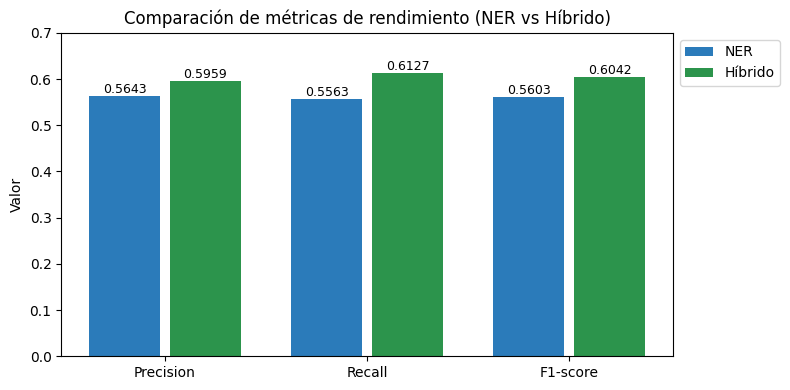

In [171]:
# =========================
# DATOS
# =========================

labels = ["Precision", "Recall", "F1-score"]

ner_values = [
    results_ner["precision"],
    results_ner["recall"],
    results_ner["f1"]
]

hybrid_values = [
    results_hybrid["precision"],
    results_hybrid["recall"],
    results_hybrid["f1"]
]


# =========================
# CONFIGURACIÓN GRÁFICA
# =========================

x = np.arange(len(labels))
width = 0.35
gap = 0.05

# Colores coherentes con clasificación
color_ner = sns.color_palette("Blues")[4]
color_hybrid = sns.color_palette("Greens")[4]


# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2 - gap/2, ner_values, width, label="NER", color=color_ner)
bars2 = plt.bar(x + width/2 + gap/2, hybrid_values, width, label="Híbrido", color=color_hybrid)

# Configuración
plt.xticks(x, labels)
plt.ylabel("Valor")
plt.title("Comparación de métricas de rendimiento (NER vs Híbrido)")


# Límite eje Y con margen
plt.ylim(0, 0.7)

# Leyenda fuera
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# Etiquetas sobre barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.4f}",
            ha='center',
            va='bottom' if offset > 0 else 'top',
            fontsize=9
        )

plt.tight_layout()
plt.show()

El análisis de las métricas globales muestra una mejora consistente del sistema híbrido respecto al modelo NER base en las tres dimensiones evaluadas: *precision*, *recall* y *F1-score*. En concreto, la precisión aumenta de 0.5643 a 0.5959, lo que indica una ligera reducción de falsos positivos al incorporar el conocimiento de dominio. Sin embargo, la mejora más relevante se observa en el *recall*, que pasa de 0.5563 a 0.6127, evidenciando una mayor capacidad del sistema híbrido para recuperar entidades que el modelo NER no era capaz de detectar por sí solo.

Este incremento en *recall* tiene un impacto directo en el *F1-score*, que mejora de 0.5603 a 0.6042, reflejando un equilibrio más favorable entre precisión y cobertura. En conjunto, estos resultados confirman que la incorporación del diccionario permite reforzar la detección sin penalizar la calidad de las predicciones, lo que valida la utilidad del enfoque híbrido en escenarios con alta variabilidad lingüística.

##### 7.9.4.2 Análisis de cobertura en la detección de entidades

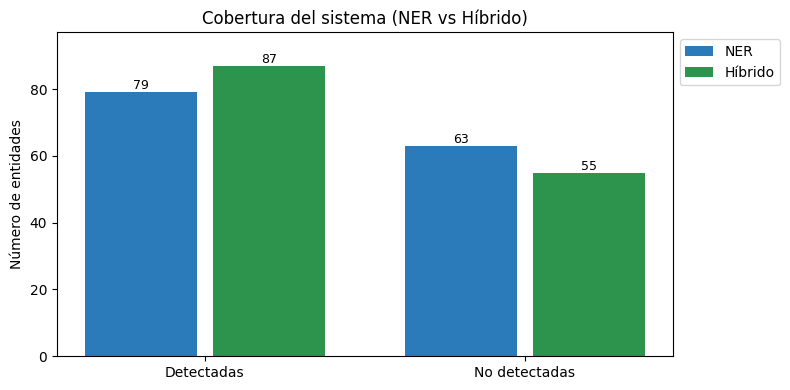

In [172]:
# =========================
# COBERTURA GLOBAL
# =========================

labels = ["Detectadas", "No detectadas"]

ner_detected = results["total_entities"] - results["total_missing"]
ner_missing = results["total_missing"]

hyb_detected = results_hybrid_analysis["total_entities"] - results_hybrid_analysis["total_missing"]
hyb_missing = results_hybrid_analysis["total_missing"]

ner_values = [ner_detected, ner_missing]
hyb_values = [hyb_detected, hyb_missing]


# =========================
# CONFIGURACIÓN GRÁFICA
# =========================

x = np.arange(len(labels))
width = 0.35
gap = 0.05

# Colores coherentes
color_ner = sns.color_palette("Blues")[4]
color_hybrid = sns.color_palette("Greens")[4]


# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2 - gap/2, ner_values, width, label="NER", color=color_ner)
bars2 = plt.bar(x + width/2 + gap/2, hyb_values, width, label="Híbrido", color=color_hybrid)

# Configuración
plt.xticks(x, labels)
plt.ylabel("Número de entidades")
plt.title("Cobertura del sistema (NER vs Híbrido)")

# Límite eje Y con margen automático
max_value = max(ner_values + hyb_values)
plt.ylim(0, max_value + 10)

# Leyenda fuera
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# Etiquetas sobre barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

El análisis de cobertura permite cuantificar el impacto real del enfoque híbrido en términos de entidades correctamente identificadas. El modelo NER base detecta 79 entidades, mientras que el sistema híbrido incrementa esta cifra hasta 87, lo que supone una mejora significativa en términos absolutos. De forma complementaria, el número de entidades no detectadas se reduce de 63 a 55, lo que evidencia una mejora clara en la capacidad de recuperación de información relevante.

Este comportamiento es coherente con la mejora observada en el *recall* y confirma que el diccionario actúa como mecanismo efectivo de recuperación de entidades no vistas durante el entrenamiento. No obstante, la existencia de 55 entidades no detectadas (38.73%) indica que aún existe un margen considerable de mejora, especialmente en aquellas categorías donde el diccionario no resulta suficiente o donde la variabilidad de expresión es elevada.

##### 7.9.4.3 Análisis de errores por tipo de entidad

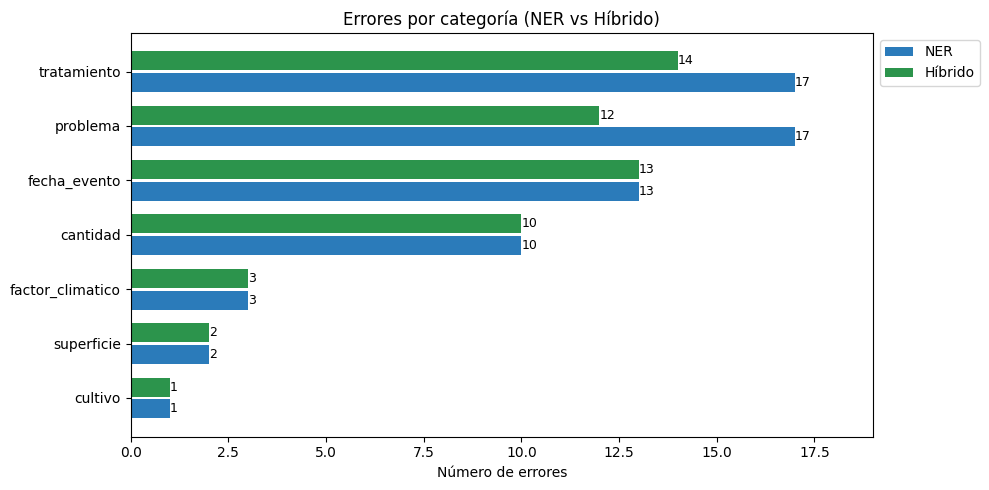

In [173]:
# =========================
# ERRORES POR CATEGORÍA
# =========================

# Convertimos a DataFrame
df_ner = pd.DataFrame(
    results["missing_by_label"].items(),
    columns=["Entidad", "NER"]
)

df_hybrid = pd.DataFrame(
    results_hybrid_analysis["missing_by_label"].items(),
    columns=["Entidad", "Híbrido"]
)

# Merge
df_compare = pd.merge(df_ner, df_hybrid, on="Entidad")

# Ordenar por NER
df_compare = df_compare.sort_values(by="NER", ascending=True)


# =========================
# CONFIGURACIÓN GRÁFICA
# =========================

y = np.arange(len(df_compare))
height = 0.35
gap = 0.05

# Colores coherentes
color_ner = sns.color_palette("Blues")[4]
color_hybrid = sns.color_palette("Greens")[4]


# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(10,5))

bars1 = plt.barh(y - height/2 - gap/2, df_compare["NER"], height, label="NER", color=color_ner)
bars2 = plt.barh(y + height/2 + gap/2, df_compare["Híbrido"], height, label="Híbrido", color=color_hybrid)

# Configuración
plt.yticks(y, df_compare["Entidad"])
plt.xlabel("Número de errores")
plt.title("Errores por categoría (NER vs Híbrido)")

# Límite eje X con margen
max_value = max(df_compare["NER"].max(), df_compare["Híbrido"].max())
plt.xlim(0, max_value + 2)

# Leyenda fuera
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# Etiquetas sobre barras
for bars in [bars1, bars2]:
    for bar in bars:
        width_bar = bar.get_width()

        plt.text(
            width_bar,
            bar.get_y() + bar.get_height()/2,
            f"{int(width_bar)}",
            va='center',
            ha='left',
            fontsize=9
        )

plt.tight_layout()
plt.show()

El análisis por categoría permite identificar con mayor precisión en qué tipos de entidades el enfoque híbrido aporta valor. Se observa una reducción notable de errores en entidades de dominio como `problema` y `tratamiento`, donde el número de errores pasa de 17 a 12 y de 17 a 14 respectivamente. Esto confirma que el diccionario es especialmente eficaz en la detección de términos específicos del dominio agrícola, donde la variabilidad léxica es limitada y el conocimiento experto resulta determinante.

Por el contrario, en categorías como `fecha_evento`, `cantidad` o `factor_climatico` no se observa mejora, manteniéndose el número de errores constante. Este comportamiento es esperable, ya que estas entidades presentan una alta variabilidad lingüística y dependen en gran medida del contexto, lo que dificulta su modelado mediante reglas o diccionarios simples.

En categorías de menor frecuencia como `cultivo` o `superficie`, el número de errores es reducido en ambos enfoques, lo que indica que tanto el modelo NER como el sistema híbrido presentan un comportamiento adecuado en estos casos.

#### 7.9.5 Conclusiones del enfoque híbrido

Los resultados obtenidos permiten extraer varias conclusiones relevantes sobre el comportamiento del sistema. En primer lugar, el enfoque híbrido demuestra ser eficaz para mejorar la detección de entidades, especialmente en aquellas categorías donde el conocimiento de dominio puede ser representado de forma estructurada. La mejora en *recall* y en cobertura confirma que el diccionario complementa adecuadamente al modelo NER, permitiendo recuperar información que no ha sido aprendida durante el entrenamiento.

Sin embargo, el análisis también pone de manifiesto las limitaciones del enfoque. A pesar de la mejora, el sistema sigue presentando un 38.73% de entidades no detectadas, lo que podría parecer elevado en términos absolutos. No obstante, este valor debe interpretarse en contexto: una parte significativa de estas entidades corresponde a categorías como fecha_`evento o `cantidad`, cuya correcta identificación requiere técnicas más avanzadas de normalización y procesamiento semántico que no forman parte del alcance de este módulo.

Además, es importante considerar que el modelo ha sido entrenado con un conjunto relativamente reducido de datos (200 mensajes), lo que limita su capacidad para generalizar y capturar la variabilidad del lenguaje real. Es razonable esperar que un incremento en el volumen de datos de entrenamiento permita mejorar significativamente el rendimiento del modelo NER, reduciendo la dependencia del diccionario y aumentando la calidad global del sistema.

En este sentido, el enfoque híbrido se posiciona como una solución intermedia eficaz en escenarios con datos limitados, permitiendo compensar las carencias del modelo mediante conocimiento experto. A medida que se disponga de un mayor volumen de datos anotados, el papel del diccionario podría reducirse progresivamente, dando lugar a modelos más robustos y generalizables. En este escenario, sería posible explorar el uso de arquitecturas más avanzadas basadas en modelos de lenguaje preentrenados, como BETO u otros modelos tipo *transformer*, que permiten capturar relaciones contextuales más complejas y mejorar significativamente la capacidad de generalización en tareas de extracción de entidades.

Estos resultados ponen de manifiesto que la integración de conocimiento de dominio permite reforzar de forma efectiva la detección de entidades en escenarios reales, especialmente cuando se trabaja con conjuntos de datos limitados y con alta variabilidad lingüística.

### 7.10 Guardado del modelo para integración en *pipeline*

In [174]:
# Guardado del modelo NER entrenado
nlp.to_disk(ner_model_dir)

# Verificación de guardado
print("Modelo NER guardado en:", ner_model_dir)

Modelo NER guardado en: /Volumes/EXTENSION/GitHub/TFM/data/models/ner_model


<div style="border-left: 5px solid #4CAF50; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: #4CAF50">Nota:</strong> El modelo guardado corresponde únicamente al componente NER. El sistema híbrido completo requiere además la carga del diccionario de dominio y la aplicación de la lógica de integración definida en el <i>pipeline</i>.
</div>

## 8. Implementación y ejecución del *pipeline* de clasificación y NER

En esta sección se describe la implementación del *pipeline* completo de procesamiento del lenguaje natural, integrando los modelos de clasificación y extracción de entidades desarrollados previamente. El objetivo es construir un flujo automatizado capaz de transformar las transcripciones generadas por el sistema ASR en información estructurada, lista para su posterior tratamiento.

El diseño del *pipeline* sigue un enfoque modular, en el que cada etapa del procesamiento se implementa de forma independiente, facilitando su mantenimiento, validación y reutilización. Esta arquitectura permite desacoplar las distintas fases del sistema, garantizando su escalabilidad y facilitando futuras mejoras o sustitución de componentes.

### 8.1 Inicialización del entorno y gestión de rutas

En primer lugar, se define un sistema de gestión de rutas que permite localizar de forma automática la estructura del proyecto, estableciendo los directorios de entrada, salida y modelos. Este enfoque evita dependencias rígidas del entorno de ejecución y garantiza la portabilidad del *pipeline*.

In [ ]:
def configure_nlp_paths(base_data_dir: str = "data") -> dict:

    project_root = Path.cwd()

    # Detectar raíz del proyecto
    while not (project_root / base_data_dir).exists():
        if project_root.parent == project_root:
            raise FileNotFoundError(f"No se encontró la carpeta '{base_data_dir}'")
        project_root = project_root.parent

    data_dir = project_root / base_data_dir

    # Input
    input_dir = data_dir / "transcriptions" / "asr_output"

    # Output
    nlp_output_dir = data_dir / "structured_data" / "nlp_output"

    # Modelos
    classification_model_dir = data_dir / "models" / "classification_model"
    ner_model_dir = data_dir / "models" / "ner_model"

    # Config
    ner_terms_path = data_dir / "config" / "ner" / "coffee_cacao_ner_terms.json"

    # Crear carpetas
    nlp_output_dir.mkdir(parents=True, exist_ok=True)

    return {
        "input_dir": input_dir,
        "nlp_output_dir": nlp_output_dir,
        "classification_model_dir": classification_model_dir,
        "ner_model_dir": ner_model_dir,
        "ner_terms_path": ner_terms_path
    }

### 8.2 Carga de modelos y recursos

En esta etapa se cargan los modelos previamente entrenados y persistidos, incluyendo tanto el modelo de clasificación como el modelo NER. Asimismo, se incorporan los recursos adicionales necesarios para el funcionamiento del sistema híbrido, como el diccionario de términos de dominio.

#### 8.2.1 Carga del modelo de clasificación (Regresión Logística + TF-IDF)

In [4]:
def load_classification_model(model_dir: Path):

    vectorizer = joblib.load(model_dir / "tfidf_vectorizer.pkl")
    model = joblib.load(model_dir / "baseline_model.pkl")
    label_encoder = joblib.load(model_dir / "label_encoder.pkl")

    return vectorizer, model, label_encoder

#### Carga del modelo NER basado en spaCy

In [5]:
def load_ner_model(model_dir: Path):

    return spacy.load(model_dir)

### 8.3 Implementación de funciones del *pipeline*

Se definen las funciones que componen el flujo completo de procesamiento, manteniendo una separación clara de responsabilidades.

#### 8.3.1 Normalización del texto

Se aplica un proceso de normalización previo que garantiza la coherencia entre las fases de entrenamiento e inferencia, reduciendo la variabilidad superficial del texto sin alterar su contenido semántico.

In [6]:
def normalize_for_nlp(text: str) -> str:

    if text is None:
        return ""

    text = text.lower()
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

#### 8.3.2 Clasificación de mensajes

Se implementa la función encargada de asignar una categoría a cada mensaje, utilizando el modelo de clasificación previamente entrenado.

In [7]:
def classify_text(text: str, vectorizer, model, label_encoder):

    text_clean = normalize_for_nlp(text)

    text_tfidf = vectorizer.transform([text_clean])
    pred = model.predict(text_tfidf)

    label = label_encoder.inverse_transform(pred)[0]

    return label

#### 8.3.3 Extracción de entidades (NER)

En esta etapa se lleva a cabo la detección de entidades a partir de dos enfoques complementarios. Por un lado, se aplica el modelo NER entrenado para identificar entidades mediante aprendizaje automático. Por otro, se incorpora un mecanismo basado en diccionario de dominio que permite detectar términos relevantes no capturados por el modelo. Ambos enfoques generan conjuntos independientes de entidades que serán integrados posteriormente.

##### 8.3.3.1 Extracción de entidades mediante modelo NER (spaCy)

In [8]:
def extract_entities_ner(text: str, nlp):

    doc = nlp(text)

    return [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]

##### 8.3.3.2 Detección de entidades basada en diccionario de dominio

In [9]:
def extract_entities_from_dictionary(text: str, domain_terms):

    entities = []

    for categoria, variantes in domain_terms.items():
        for variante in variantes:

            pattern = r"\b" + re.escape(variante) + r"\b"

            for match in re.finditer(pattern, text, flags=re.IGNORECASE):
                entities.append((match.start(), match.end(), categoria))

    return entities

#### 8.3.4 Integración del enfoque híbrido

En esta etapa se realiza la integración de las entidades detectadas mediante el modelo NER y el diccionario de dominio, conformando el enfoque híbrido del sistema. La combinación se lleva a cabo respetando una jerarquía en la que las entidades identificadas por el modelo tienen prioridad, incorporando únicamente aquellas detecciones del diccionario que no generan solapamientos. Este procedimiento permite mejorar la cobertura del sistema sin introducir duplicidades ni inconsistencias en la salida final.

In [10]:
def combine_entities(ner_entities, dict_entities):

    occupied = set()

    for start, end, _ in ner_entities:
        for i in range(start, end):
            occupied.add(i)

    filtered_dict = []

    for start, end, label in dict_entities:
        if not any(i in occupied for i in range(start, end)):
            filtered_dict.append((start, end, label))

    return ner_entities + filtered_dict

#### 8.3.5 Procesamiento de mensajes individuales

Se define una función que integra todas las etapas anteriores, permitiendo procesar un único mensaje y generar una salida estructurada que incluya tanto la clasificación como las entidades detectadas.

In [11]:
def process_single_message(
    data,
    vectorizer,
    clf_model,
    label_encoder,
    nlp,
    domain_terms
):

    text = data.get("text", "")

    # Clasificación
    label = classify_text(text, vectorizer, clf_model, label_encoder)
    data["prediction"] = label

    # NER
    ner_entities = extract_entities_ner(text, nlp)

    # Diccionario
    dict_entities = extract_entities_from_dictionary(text, domain_terms)

    # Híbrido
    entities = combine_entities(ner_entities, dict_entities)

    # Formato final
    data["entities"] = [
        {
            "text": text[start:end],
            "label": ent_label
        }
        for start, end, ent_label in entities
    ]

    # Metadata de procesamiento

    data["processing_version"] = "1.0"
    
    return data

#### 8.3.6 Guardado de resultados del pipeline

In [12]:
def save_enriched_json(data: dict, output_dir: Path):

    # Construcción de la ruta de salida
    output_path = output_dir / f"{data['audio_id']}.json"

    # Escritura del archivo JSON
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

#### 8.3.7 Procesamiento del conjunto de datos

Se implementa el recorrido completo sobre el conjunto de archivos generados por el sistema ASR, aplicando el *pipeline* de forma secuencial sobre cada mensaje y almacenando los resultados obtenidos.

In [13]:
def process_full_pipeline(
    input_dir,
    output_dir,
    vectorizer,
    clf_model,
    label_encoder,
    nlp,
    domain_terms
):

    json_files = sorted(input_dir.glob("*.json"))

    if not json_files:
        raise FileNotFoundError("No se encontraron JSONs ASR")

    for json_file in tqdm(json_files):

        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        enriched = process_single_message(
            data,
            vectorizer,
            clf_model,
            label_encoder,
            nlp,
            domain_terms
        )

        # Guardado desacoplado
        save_enriched_json(enriched, output_dir)

### 8.4 Ejecución del *pipeline* completo

Se ejecuta el flujo completo de procesamiento, integrando todas las funciones definidas previamente. Esta etapa permite transformar automáticamente el conjunto de transcripciones en salidas estructuradas listas para su uso en etapas posteriores del sistema.

In [14]:
print("Inicializando pipeline NLP...")

paths = configure_nlp_paths()

vectorizer, clf_model, label_encoder = load_classification_model(
    paths["classification_model_dir"]
)

nlp = load_ner_model(paths["ner_model_dir"])

with open(paths["ner_terms_path"], "r", encoding="utf-8") as f:
    domain_terms = json.load(f)

process_full_pipeline(
    paths["input_dir"],
    paths["nlp_output_dir"],
    vectorizer,
    clf_model,
    label_encoder,
    nlp,
    domain_terms
)

print("Pipeline NLP completado correctamente")

Inicializando pipeline NLP...


100%|██████████| 200/200 [00:01<00:00, 135.62it/s]

Pipeline NLP completado correctamente


### 8.5 Validación del *pipeline*

Finalmente, se realiza una validación del funcionamiento del *pipeline*, comprobando la consistencia de los resultados generados, la integridad de los datos y la correcta integración de los distintos componentes del sistema.

In [24]:
# =========================
# VALIDACIÓN DE RESULTADOS
# =========================

print("\nValidando resultados...")

# Obtener lista de archivos generados
output_files = sorted(paths["nlp_output_dir"].glob("*.json"))

# Verificar que existen resultados
assert output_files, "No hay resultados generados por el pipeline"

# Recorrido de validación
for file in output_files:

    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Validación de estructura básica
    assert "audio_id" in data
    assert "text" in data
    assert "prediction" in data
    assert "entities" in data

    # Validación de tipos
    assert isinstance(data["audio_id"], str)
    assert isinstance(data["text"], str)
    assert isinstance(data["prediction"], str)
    assert isinstance(data["entities"], list)

    # Validación de entidades
    for ent in data["entities"]:
        assert "text" in ent
        assert "label" in ent
        assert isinstance(ent["text"], str)
        assert isinstance(ent["label"], str)

print(f"✔ {len(output_files)} archivos validados correctamente")


# =========================
# EJEMPLO DE SALIDA
# =========================

# Selección manual de archivo (por índice)
sample_index = 1  # Cambiar índice para inspeccionar otro ejemplo
sample_file = output_files[sample_index]

with open(sample_file, "r", encoding="utf-8") as f:
    sample_data = json.load(f)

print("\n--- Ejemplo de salida ---\n")
print(f"Audio ID: {sample_data['audio_id']}")
print(f"Texto: {sample_data['text']}")
print(f"Predicción: {sample_data['prediction']}")
print(f"Versión de procesamiento: {sample_data.get('processing_version', 'N/A')}")
print("Entidades:")
for ent in sample_data["entities"]:
    print(f"  - {ent['text']} ({ent['label']})")


Validando resultados...
✔ 200 archivos validados correctamente

--- Ejemplo de salida ---

Audio ID: AUDIO_00002
Texto: Mi nombre es Luis Fernando Taborda, soy productor de café en la vereda El Tambo, municipio de El Tambo, departamento de Cauca, Colombia.  Actualmente manejo aproximadamente 7 hectáreas sembradas con variedad castillo bajo un sistema agroforestal con sombra de guavos y algunos frutales, trabajando con apoyo técnico para mejorar la producción.
Predicción: registro_inicial
Versión de procesamiento: 1.0
Entidades:
  - café (cultivo)
  - El Tambo (localidad)
  - El Tambo (localidad)
  - Cauca (region)
  - Colombia (pais)
  - 7 hectáreas (superficie)
  - castillo (variedad)
  - guavos (especie_sombra)
  - frutales (especie_sombra)


## 8. Conclusiones

Los resultados obtenidos a lo largo de este *notebook* permiten evaluar de forma global el comportamiento del sistema de procesamiento del lenguaje natural propuesto, considerando tanto la tarea de clasificación de mensajes como la extracción de entidades.

En el caso de la **clasificación**, los modelos evaluados han alcanzado un rendimiento muy elevado, con valores de *F1-score* cercanos a 1.0 en el conjunto de test. Estos resultados indican que el sistema es capaz de discriminar correctamente entre las distintas categorías definidas (`registro_inicial`, `evento_cultivo`), mostrando una alta capacidad de aprendizaje incluso con un volumen de datos relativamente limitado. No obstante, este comportamiento debe interpretarse con cautela, ya que el tamaño del conjunto de datos y su posible homogeneidad limitan la variabilidad de los ejemplos disponibles, lo que puede influir en la estabilidad de los resultados. En este sentido, la incorporación futura de nuevos ejemplos más diversos permitiría validar la robustez real del modelo en escenarios más exigentes y representativos del entorno real.

En cuanto a la **extracción de entidades (NER)**, los resultados muestran un rendimiento más moderado. El modelo basado en spaCy alcanza valores en torno a *precision* $\approx$ 0.56, *recall* $\approx$ 0.56 y *F1-score* $\approx$ 0.56 en el conjunto de evaluación independiente, lo que refleja una capacidad limitada para generalizar a textos no vistos. Este comportamiento se ve reforzado por el análisis de errores, donde se observa una proporción significativa de entidades no detectadas ($\approx$ 44%), concentradas principalmente en categorías con alta variabilidad lingüística como fecha_evento, cantidad o tratamiento.

La incorporación de un **enfoque híbrido**, combinando el modelo NER con un diccionario de dominio, permite mejorar de forma consistente el rendimiento del sistema. En concreto, se observa un incremento del *F1-score* hasta valores cercanos a 0.60, acompañado de una mejora en la cobertura, reduciendo el porcentaje de entidades no detectadas hasta aproximadamente un 38.73%. Esta mejora, aunque moderada, confirma que la integración de conocimiento de dominio permite recuperar entidades que no habían sido aprendidas durante el entrenamiento.

No obstante, el análisis también evidencia que esta mejora no es homogénea para todos los tipos de entidades. El enfoque híbrido resulta especialmente útil en categorías de dominio como `problema` o `tratamiento`, mientras que su impacto es limitado en entidades más variables y dependientes del contexto, como `fecha_evento` o `cantidad`. Esto pone de manifiesto que el rendimiento del sistema no depende únicamente del modelo, sino también de la naturaleza de las entidades a extraer.

Asimismo, el porcentaje de entidades no detectadas pone de manifiesto una limitación relevante del sistema. Una parte relevante de estos casos corresponde a expresiones complejas o altamente variables, cuya correcta identificación requeriría técnicas adicionales de normalización o un mayor volumen de datos de entrenamiento, más que ajustes en la arquitectura actual.

Además, es importante considerar que el modelo ha sido entrenado con un conjunto relativamente reducido de datos (200 mensajes), lo que limita su capacidad para generalizar y capturar la variabilidad del lenguaje real. En este contexto, aunque existen alternativas basadas en modelos más avanzados como BETO o arquitecturas tipo BERT, su uso no resulta óptimo en la situación actual, ya que requieren un volumen considerable de datos anotados para alcanzar su máximo rendimiento.

Sin embargo, estas aproximaciones sí se plantean como una línea de evolución natural del sistema. Con un incremento significativo del conjunto de datos, en el orden de 1000 o 2000 audios anotados, el uso de modelos basados en *transformers* podría convertirse en una alternativa viable y potencialmente superior, reduciendo la necesidad de incorporar reglas o diccionarios y mejorando la capacidad de generalización.

El sistema desarrollado responde de forma adecuada a los objetivos planteados, mostrando un buen rendimiento en clasificación y una mejora clara en la detección de entidades gracias al enfoque híbrido. Aunque todavía existen limitaciones, especialmente en la generalización y en ciertas categorías más complejas, el comportamiento observado es coherente con el tamaño y la naturaleza de los datos utilizados.

Además, la forma en la que se ha estructurado el sistema permite seguir evolucionándolo de manera progresiva, incorporando nuevos datos y mejoras en los modelos sin necesidad de modificar la arquitectura actual, lo que lo convierte en una base sólida para futuras ampliaciones.